# Notebook 04. 모형 선택과 강건성 검증

## 분석 질문

Q1~Q3와 Triage 위에서 검토했던 ELECTRE TRI-B/SMAA-TRI를 전체 자동판정이 아니라 추가확인군의 선택적 재검토로 한정한 근거는 무엇인가?

- <b>선행 단계</b> — `03_triage.ipynb`에서 180건을 관찰 128 / 추가확인 35 / 우선점검 17로 선별하고, 추가확인 35건만 선택적 ELECTRE/SMAA 재검토로 넘긴다는 경로를 확인했다.

## 입력

| 구분 | 경로 |
|---|---|
| ELECTRE 파라미터 등록·규칙 대비 배정·최종 판정 | `logs/experiments/archived_outputs/candidate_models/{electre_parameter_registry,electre_vs_rule_comparison,electre_final_decision}.csv` |
| 자료개정 교란 강건성(C3b)·한계 기록 | `logs/experiments/archived_outputs/candidate_models/{electre_interval_robustness,electre_limitation_record}.csv` |
| SMAA 선택적 재검토 결과·요약 | `outputs/final_model/03_electre_smaa/tables/{electre_smaa_review_cases,electre_smaa_summary}.csv` |
| 독립 감사 | `logs/validation/audits/independent_audit/{REPORT.md,findings.csv,summary.json}` |
| Triage 규칙·원본 마스터(재실행용) | `src/triage/{triage_rule.py,run_triage.py,triage_audit.py}`, `data/processed/kicox/{changwon_industry_master.csv,changwon_state_panel.csv}` |
| Triage 민감도(저장본, 대조용) | `logs/validation/triage/{sensitivity_own_rules,sensitivity_changed_rows}.csv` |
| 시점 분리 검증 | `logs/validation/outputs/{rolling_backtest,hybrid_validation}/*` |
| PPI 보정 실험 | `src/evidence/modules/ppi_adjusted.py`, `logs/validation/outputs/robustness_extension/{nominal_real_disagreement,signal_threshold_sensitivity}.csv` |
| KEPCO 전력 강건성 | `logs/validation/outputs/kepco_robustness/*` |
| 최종 Triage 패널·재검토 입력 키 | `outputs/final_model/02_triage/tables/triage_panel.csv`, `data/processed/final_model/electre_smaa_check_cases.csv` |

## 출력

이 노트북은 새 표·그림 파일을 저장하지 않는다. 저장된 실험 산출물을 불러와 표시하고(PART A·B·C·D·F·G·H), `src/triage/triage_rule.py`의 `compute_axes`·`apply_rule`은 노트북 안에서 실제로 다시 불러와 재실행한다(PART E).

<b>Figure</b> (노트북 안에서만 표시)

| 내용 |
|---|
| ELECTRE 자료개정 교란 강건성 C3b 막대(사전 기준 0.95) |
| SMAA 수용도(Class Acceptability Index) 누적막대 |
| Triage 사양별 변경행 막대·stage 분포 누적막대(재실행 결과) |
| 명목 vs PPI 조정 생산 YoY 산점도 |

## 구성

| 파트 | 내용 | 성격 |
|---|---|---|
| A | ELECTRE TRI-B 주모형 후보 검토 | 인용 |
| B | 자료개정 교란 강건성(C3b) | 인용 |
| C | SMAA-TRI 파라미터 불확실성 | 인용 |
| D | 독립 감사 | 인용 |
| E | Triage 민감도·ablation | <b>재실행</b> |
| F | 시점 분리 검증(rolling/hybrid) | 인용 |
| G | PPI 보정 실험 | 인용 |
| H | KEPCO 전력 강건성 | 인용 |
| I | 최종 모형 선택과 경로 재검증 | 확증 |

## 전체 수행 흐름

1. 코드 인용 도구(`show_source`)를 준비하고 실험 산출물을 모두 불러온다.
2. ELECTRE TRI-B 시나리오 등록값과 규칙 대비 배정 결과, 최종 판정 기록을 본다(PART A).
3. employment·production 실측 개정폭으로 자료를 교란한 강건성 지표 C3b를 본다(PART B).
4. SMAA-TRI 파라미터 표집으로 만든 등급수용지수(CAI)를 본다(PART C).
5. 독립 감사가 지적한 항목과 실제 조치를 본다(PART D).
6. `triage_rule.py`의 상수와 `compute_axes`·`apply_rule`을 그대로 불러와 baseline과 15개 변형 사양을 <b>노트북에서 직접 재실행</b>하고, 저장된 민감도 표와 값이 같은지 확인한다(PART E).
7. 확정 사양을 시점을 나눠 과거 자료에 적용한 rolling/hybrid 결과를 본다(PART F).
8. 명목 생산과 PPI 조정 생산의 불일치를 본다(PART G).
9. KEPCO 전력사용량 교차확인 결과를 본다(PART H).
10. 후보별 역할을 정리하고, Triage 추가확인·ELECTRE 입력·최종 선택패널의 키가 일치하는지 다시 검증한다(PART I).

```text
Q1~Q3 유형화
      ↓
ELECTRE TRI-B 주모형 후보 등록 (A)
      ↓
자료개정 교란(B) · 파라미터 불확실성(C) · 독립감사(D)
      ↓
Triage 민감도 재실행(E) · 시점분리(F) · PPI(G) · KEPCO(H)
      ↓
현재 구조: 규칙 기반 Triage(1차 선별) + 추가확인 35건만 선택적 ELECTRE/SMAA (I)
```

**프로젝트 역사**와 **현재 운영구조**를 구분한다. 과거 180행 전체 실험은 후보모형 검증 기록이고, 현재 ELECTRE/SMAA는 추가확인 35건에만 쓰는 advisory layer다.

## 0단계. 환경 설정과 코드 인용 도구

### 무엇을 준비하나

- 표시용 함수(`show_table`,`show_records`)에 더해 `show_source()`를 추가한다. 함수 객체를 넘기면 그 함수의 실제 소스를, 파일 경로와 줄 범위를 넘기면 그 구간을 그대로 코드블록으로 보여준다.
- 이 노트북은 "실험을 했다"는 서술이 아니라, 저장소에 남아 있는 원본 `.py` 구현과 저장된 산출물을 그대로 근거로 쓴다.

In [1]:
from pathlib import Path
import sys, json, inspect, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir())
sys.path.insert(0, str(ROOT / 'src'))
from utils import notebook_config as config
from core.analysis.config import setup_matplotlib
setup_matplotlib()
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def _md_value(value):
    if pd.isna(value): return '—'
    if isinstance(value, (float, np.floating)): return f'{value:,.3f}'
    return str(value).replace('|', '\\|').replace('\n', ' / ')

def show_table(frame, max_rows=30):
    view = frame.head(max_rows)
    header = '| ' + ' | '.join(map(str, view.columns)) + ' |'
    rule = '| ' + ' | '.join(['---'] * len(view.columns)) + ' |'
    rows = ['| ' + ' | '.join(_md_value(v) for v in row) + ' |' for row in view.itertuples(index=False, name=None)]
    note = f'\n\n*상위 {max_rows}행만 표시*' if len(frame) > max_rows else ''
    display(Markdown('\n'.join([header, rule, *rows]) + note))

def show_records(frame, title_col, fields=None, max_rows=30):
    fields = fields or [c for c in frame.columns if c != title_col]
    blocks = []
    for _, row in frame.head(max_rows).iterrows():
        blocks.append('#### ' + _md_value(row[title_col]))
        blocks.extend(f'- **{c}:** {_md_value(row[c])}' for c in fields)
    if len(frame) > max_rows: blocks.append(f'*상위 {max_rows}건만 표시*')
    display(Markdown('\n\n'.join(blocks)))

def show_source(obj_or_path, start=None, end=None, lang='python'):
    '''함수 객체면 소스 전체를, 경로면 지정한 줄 범위를 코드블록으로 보여준다.'''
    if callable(obj_or_path):
        src = inspect.getsource(obj_or_path)
        srcfile = Path(inspect.getsourcefile(obj_or_path))
        try:
            label = srcfile.relative_to(ROOT).as_posix()
        except ValueError:
            label = srcfile.name
        where = f'{label}:{inspect.getsourcelines(obj_or_path)[1]}'
    else:
        p = Path(obj_or_path)
        lines = p.read_text(encoding='utf-8').splitlines()
        src = '\n'.join(lines[(start or 1) - 1:end])
        try:
            label = p.relative_to(ROOT).as_posix()
        except ValueError:
            label = p.as_posix()
        where = f'{label}:{start}-{end}'
    display(Markdown(f'`{where}`\n\n```{lang}\n{textwrap.dedent(src)}\n```'))

STAGE_ORDER = ['관찰', '추가확인', '우선점검', '자료확인']
STAGE_COLORS = {'관찰': '#7895A8', '추가확인': '#D39A2C', '우선점검': '#C5523F', '자료확인': '#777777'}

In [2]:
EXPERIMENT_DIR = ROOT / 'logs/experiments/archived_outputs/candidate_models'
ELECTRE_MRSORT_MODEL_DIR = ROOT / 'logs/experiments/electre_mrsort/src/model'
AUDIT_DIR = ROOT / 'logs/validation/audits/independent_audit'
ROLLING_DIR = ROOT / 'logs/validation/outputs/rolling_backtest'
HYBRID_DIR = ROOT / 'logs/validation/outputs/hybrid_validation'
ROBUSTNESS_DIR = ROOT / 'logs/validation/outputs/robustness_extension'
KEPCO_DIR = ROOT / 'logs/validation/outputs/kepco_robustness'
TEMPORAL_CODE_DIR = ROOT / 'logs/validation/code'

params = pd.read_csv(config.ELECTRE_PARAMETER_PATH, encoding='utf-8-sig')
vs_rule = pd.read_csv(EXPERIMENT_DIR / 'electre_vs_rule_comparison.csv', encoding='utf-8-sig')
final_decision = pd.read_csv(EXPERIMENT_DIR / 'electre_final_decision.csv', encoding='utf-8-sig')
robust = pd.read_csv(config.ELECTRE_ROBUSTNESS_PATH, encoding='utf-8-sig')
limitations = pd.read_csv(config.ELECTRE_LIMITATION_PATH, encoding='utf-8-sig')
review = pd.read_csv(config.ELECTRE_REVIEW_PATH, encoding='utf-8-sig')
smaa_summary = pd.read_csv(config.ELECTRE_SUMMARY_PATH, encoding='utf-8-sig')
source_review = pd.read_csv(config.ELECTRE_SOURCE_PATH, encoding='utf-8-sig')
sensitivity_saved = pd.read_csv(config.TRIAGE_SENSITIVITY_PATH, encoding='utf-8-sig')
changed_saved = pd.read_csv(config.TRIAGE_SENSITIVITY_CHANGED_PATH, encoding='utf-8-sig')
ppi = pd.read_csv(config.PPI_DISAGREEMENT_PATH, encoding='utf-8-sig')
signal_sensitivity = pd.read_csv(ROBUSTNESS_DIR / 'signal_threshold_sensitivity.csv', encoding='utf-8-sig')
triage = pd.read_csv(config.TRIAGE_PANEL_PATH, encoding='utf-8-sig')

audit_findings = pd.read_csv(AUDIT_DIR / 'findings.csv', encoding='utf-8-sig')
with open(AUDIT_DIR / 'summary.json', encoding='utf-8') as f:
    audit_summary = json.load(f)

rolling_metrics = pd.read_csv(ROLLING_DIR / 'metrics_long.csv', encoding='utf-8-sig')
rolling_coverage = pd.read_csv(ROLLING_DIR / 'operational_coverage.csv', encoding='utf-8-sig')
with open(ROLLING_DIR / 'PREDICTION_LOCK.json', encoding='utf-8') as f:
    rolling_lock = json.load(f)
hybrid_metrics = pd.read_csv(HYBRID_DIR / 'hybrid_metrics.csv', encoding='utf-8-sig')

with open(KEPCO_DIR / 'results_summary.json', encoding='utf-8') as f:
    kepco_summary = json.load(f)
kepco_completeness = pd.read_csv(KEPCO_DIR / 'quarterly_completeness.csv', encoding='utf-8-sig')
kepco_by_stage = pd.read_csv(KEPCO_DIR / 'power_by_stage.csv', encoding='utf-8-sig')

print('실험 산출물 로드 완료:', {
    'ELECTRE 시나리오': len(params), 'C3b 등 강건성 행': len(robust),
    '추가확인 재검토': len(review), '독립감사 지적': len(audit_findings), 'PPI 불일치·경계변경': len(ppi),
})

실험 산출물 로드 완료: {'ELECTRE 시나리오': 3, 'C3b 등 강건성 행': 14, '추가확인 재검토': 35, '독립감사 지적': 14, 'PPI 불일치·경계변경': 15}


## A. ELECTRE TRI-B 주모형 후보 검토

### 무엇을 확인하려 했나

Q1~Q3 축(고용감소·상대열위·절대비중·생산감소)은 단위가 서로 다르다. 한 기준의 큰 값이 다른 기준의 약점을 자동으로 상쇄하게 하고 싶지 않아, 비보상적 outranking과 사전 경계 profile을 쓰는 ELECTRE TRI-B가 180행 전체의 주 분류모형이 될 수 있는지 확인했다.

이 결과는 `logs/experiments/archived_outputs/candidate_models/{electre_parameter_registry,electre_vs_rule_comparison,electre_final_decision}.csv`에 저장된 실행 산출물이다. 코드는 `logs/experiments/electre_mrsort/src/model/{electre.py,params.py}`이다.

In [3]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'electre.py', 86, 127)

`logs/experiments/electre_mrsort/src/model/electre.py:86-127`

```python
def evaluate(values, scenario, support_removed=None):
    """행별 경계 비교와 점검단계.

    values : g1~g4 열을 가진 DataFrame(결측은 NaN)
    support_removed : criterion_support_removed_no_renormalization 분석에서 지지를 0으로 둘 기준.
                      가중치는 재정규화하지 않는다.
    """
    crit = config.CRITERIA
    index = values.index
    scorable = values[list(crit)].notna().all(axis=1).to_numpy()
    unscorable = ~scorable
    out = pd.DataFrame(index=index)
    outranks = {}
    for h in BOUNDARIES:
        prof = scenario.profile(h)
        c = {}
        for j in crit:
            cj = partial_concordance(values[j], prof[j])
            if support_removed == j:
                cj = np.where(np.isnan(cj), np.nan, 0.0)
            c[j] = cj
            out[f'pass_{j}_{h}'] = derive.masked_bool(cj == 1, np.isnan(cj), index)
        concordance = np.where(scorable, sum(scenario.weights[j] * np.nan_to_num(c[j]) for j in crit), np.nan)
        credibility = concordance  # veto 없음: σ = C
        with np.errstate(invalid='ignore'):
            before_gate = scorable & (credibility >= scenario.lam - EPS)
        emp_evidence = scorable & np.any([c[j] == 1 for j in config.EMPLOYMENT_CRITERIA], axis=0)
        production_only = (scorable & (c['g3'] == 1) & (scenario.weights['g3'] >= scenario.lam - EPS)
                           & ~emp_evidence)
        if not np.array_equal(production_only, before_gate & ~emp_evidence):
            raise AssertionError('생산 단독 통과 조건이 outranking 결과와 일치하지 않습니다.')
        final = before_gate & (emp_evidence | (not scenario.require_employment_evidence))
        out[f'concordance_{h}'] = concordance
        out[f'outranks_{h}_before_gate'] = derive.masked_bool(before_gate, unscorable, index)
        out[f'emp_evidence_at_{h}'] = derive.masked_bool(emp_evidence, unscorable, index)
        out[f'production_only_pass_{h}'] = derive.masked_bool(production_only, unscorable, index)
        out[f'outranks_{h}'] = derive.masked_bool(final, unscorable, index)
        outranks[h] = final
    out['scorable'] = scorable
    out['display_class_by_scenario'] = pessimistic_assignment(outranks['b1'], outranks['b2'], scorable)
    return out

```

In [4]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'params.py', 363, 405)

`logs/experiments/electre_mrsort/src/model/params.py:363-405`

```python
def parameter_register_frame(doc, validation):
    """파라미터 버전×시나리오×항목 등록부. 비어 있는 값은 MISSING으로 남긴다."""
    rows = []
    registration = doc.get('registration') or {}
    approval = doc.get('approval') or {}
    common = {
        'parameter_set_id': doc.get('parameter_set_id'),
        'parameter_file': validation.parameter_file,
        'parameter_file_present': validation.parameter_file_present,
        'declared_parameter_status': validation.declared_status,
        'effective_parameter_status': validation.effective_status,
        'run_mode': validation.run_mode,
        'registered_at': registration.get('registered_at'),
        'registered_by': registration.get('registered_by'),
        'briefing_doc_sha256': registration.get('briefing_doc_sha256'),
        'parameter_file_sha256': registration.get('parameter_file_sha256'),
        'approved_at': approval.get('approved_at'),
        'approved_scenario_id': approval.get('approved_scenario_id'),
        'approved_parameter_file_sha256': approval.get('approved_parameter_file_sha256'),
        'approved_scenario_block_sha256': approval.get('approved_scenario_block_sha256'),
        'approver_role': approval.get('approver_role'),
        'approver_org': approval.get('approver_org'),
        'model_spec_version': config.MODEL_SPEC_VERSION,
    }

    def add(scenario_id, parameter, criterion, boundary, value):
        rows.append({**common, 'scenario_id': scenario_id, 'parameter': parameter,
                     'criterion': criterion, 'boundary': boundary,
                     'value': value, 'value_status': 'MISSING' if value is None else 'PROVIDED'})

    for s in doc.get('scenarios') or []:
        if not isinstance(s, dict):
            continue
        sid = s.get('scenario_id')
        for g in config.CRITERIA:
            add(sid, 'weight', g, None, (s.get('weights') or {}).get(g))
        for h in ('b1', 'b2'):
            for g in config.CRITERIA:
                add(sid, 'profile', g, h, ((s.get('profiles') or {}).get(h) or {}).get(g))
        add(sid, 'lambda', None, None, s.get('lambda'))
        add(sid, 'delta_emp', None, None, s.get('delta_emp'))
        add(sid, 'require_employment_evidence', None, None, s.get('require_employment_evidence'))
    return pd.DataFrame(rows)
```

In [5]:
pcols = ['scenario_id', 'weight_g1', 'weight_g2', 'weight_g3', 'weight_g4',
         'b1_g1', 'b1_g2', 'b1_g3', 'b1_g4', 'b2_g1', 'b2_g2', 'b2_g3', 'b2_g4',
         'lambda', 'q', 'p', 'veto', 'assignment_rule', 'administratively_approved']
show_table(params[pcols])

agree = vs_rule.groupby('scenario_id').stage_agrees.agg(['sum', 'count'])
agree['agree_pct'] = (agree['sum'] / agree['count'] * 100).round(1)
show_table(agree.reset_index().rename(columns={'sum': 'agree_rows', 'count': 'total_rows'}))

dcols = ['block_type', 'model_id', 'scenario_id', 'overall_status', 'blocked_by', 'retained_as_official']
show_table(final_decision[dcols])

| scenario_id | weight_g1 | weight_g2 | weight_g3 | weight_g4 | b1_g1 | b1_g2 | b1_g3 | b1_g4 | b2_g1 | b2_g2 | b2_g3 | b2_g4 | lambda | q | p | veto | assignment_rule | administratively_approved |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 기준 | 0.200 | 0.200 | 0.300 | 0.300 | 100 | 2.000 | 5.000 | 2 | 500 | 5.000 | 10.000 | 4 | 0.500 | 0 | 0 | — | pessimistic | False |
| 고용중시 | 0.300 | 0.300 | 0.200 | 0.200 | 100 | 2.000 | 5.000 | 2 | 500 | 5.000 | 10.000 | 4 | 0.600 | 0 | 0 | — | pessimistic | False |
| 지속성중시 | 0.200 | 0.200 | 0.200 | 0.400 | 100 | 2.000 | 5.000 | 2 | 500 | 5.000 | 10.000 | 4 | 0.600 | 0 | 0 | — | pessimistic | False |

| scenario_id | agree_rows | total_rows | agree_pct |
| --- | --- | --- | --- |
| 고용중시 | 140 | 180 | 77.800 |
| 기준 | 177 | 180 | 98.300 |
| 지속성중시 | 171 | 180 | 95.000 |

| block_type | model_id | scenario_id | overall_status | blocked_by | retained_as_official |
| --- | --- | --- | --- | --- | --- |
| point_assignment | v1.0_crisp | 기준 | BLOCKED_MULTIPLE | C3,C4,S1 | False |
| point_assignment | v1.0_crisp | 고용중시 | BLOCKED_MULTIPLE | C2,C3,S1 | False |
| point_assignment | v1.0_crisp | 지속성중시 | BLOCKED_MULTIPLE | C3,C4,S1 | False |
| point_assignment | D_small_indifference | 기준 | BLOCKED_MULTIPLE | C3,S1 | False |
| point_assignment | D_small_indifference | 고용중시 | BLOCKED_MULTIPLE | C2,C3,S1 | False |
| point_assignment | D_small_indifference | 지속성중시 | BLOCKED_MULTIPLE | C3,S1 | False |
| interval_assignment | — | — | INTERVAL_BLOCKED_BY_I3 | — | True |

### 관찰 결과

- 등록된 시나리오는 3개(기준, 고용중시, 지속성중시)이고 profile·lambda는 시나리오 간 b1=(100,2,5,2)·b2=(500,5,10,4)로 고정, weight와 lambda만 다르다.
- 규칙 기반 배정과의 일치율은 기준 시나리오 177/180(98.3%), 지속성중시 171/180(95.0%), 고용중시 140/180(77.8%)다.
- `electre_final_decision.csv`에서 점 배정 조합 6개(v1.0_crisp·D_small_indifference × 3개 시나리오)는 모두 `BLOCKED_MULTIPLE`이며 `retained_as_official=False`다. 구간배정 결과는 `INTERVAL_BLOCKED_BY_I3`로 기록되고, 이 기록 자체가 공식 판정으로 남았다(`retained_as_official=True`이지만 상태는 통과가 아니라 차단이다).

### 최종 설계에 미친 영향

점 배정 시나리오 중 공식 채택(`retained_as_official`)된 것은 없다. 구조 자체는 등록·구현 검사를 통과했지만, 아래 B·C·D의 강건성·불확실성 기준을 충족하지 못해 전체 자동판정 후보에서 제외됐다.

## B. 자료개정 교란 강건성(C3b, 사전 기준 0.95)

### 무엇을 확인하려 했나

ELECTRE 점 배정이 employment·production 원자료의 실측 개정폭(vintage)만큼 흔들려도 판정을 유지하는지 확인한다. 사전 등록한 합격선은 0.95다.

이 결과는 `logs/experiments/archived_outputs/candidate_models/{electre_interval_robustness,electre_limitation_record}.csv`에 저장된 실행 산출물이다. 코드는 `logs/experiments/electre_mrsort/src/model/perturb.py`이다.

In [6]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'perturb.py', 16, 27)

`logs/experiments/electre_mrsort/src/model/perturb.py:16-27`

```python
def revision_pool(path):
    """vintage_수정폭_실측.csv에서 변수별(employment·production) 수정율(비율) 배열.

    반환: {'employment': ndarray, 'production': ndarray}. 값은 수정율pct/100(비율)이며
    NaN은 제외한다.
    """
    df = pd.read_csv(path, encoding='utf-8-sig')
    df.columns = [str(c).lstrip('﻿') for c in df.columns]
    pool = {}
    for var in ('employment', 'production'):
        vals = df.loc[df['변수'] == var, '수정율pct'].astype(float).to_numpy() / 100.0
        pool[var] = vals[~np.isnan(vals)]
```

In [7]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'perturb.py', 67, 89)

`logs/experiments/electre_mrsort/src/model/perturb.py:67-89`

```python
def perturb_once(panel, pool, rng):
    """employment·employment_lag4·production·production_lag4에 독립 복원추출 승수
    (1+r)를 곱하고 g1~g4를 재계산한 DataFrame(panel과 같은 행순서·인덱스)을 돌려준다.
    """
    out = panel.copy()
    for column in PERTURBED_COLUMNS:
        var = 'employment' if column.startswith('employment') else 'production'
        r = rng.choice(pool[var], size=len(out), replace=True)
        out[column] = out[column].astype(float) * (1.0 + r)

    lag4_positive = out['production_lag4'].gt(0)
    out['production_yoy'] = ((out['production'] / out['production_lag4'] - 1.0) * 100.0).where(
        lag4_positive & out['production'].notna())
    emp_lag4_positive = out['employment_lag4'].gt(0)
    out['employment_yoy'] = ((out['employment'] / out['employment_lag4'] - 1.0) * 100.0).where(
        emp_lag4_positive & out['employment'].notna())

    out[config.CRITERION_COLUMNS['g1']] = np.maximum(0.0, out['employment_lag4'] - out['employment'])
    out[config.CRITERION_COLUMNS['g2']] = np.maximum(0.0, -out['employment_yoy'])
    out[config.CRITERION_COLUMNS['g3']] = np.maximum(0.0, -out['production_yoy'])
    out['g4_delta00'] = _recompute_g4_delta00(panel, out['employment_yoy'].to_numpy(dtype=float))
    return out

```

In [8]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'perturb.py', 111, 137)

`logs/experiments/electre_mrsort/src/model/perturb.py:111-137`

```python
def stability(panel, scenario, q, p, veto, pool, n=400, seed=99):
    """교란 재표집에서 판정단계 유지율 분포.

    분모는 두 단계(교란 전·후) 모두 UNDETERMINED가 아닌 행만 포함한다(결측 여부는
    자료 교란과 무관하게 원래부터 정해져 있으므로 이 필터는 거의 항상 전체 완전관측
    행과 같다).
    반환: {'mean','p05','min','replicates': ndarray(길이 n, 실패 시 nan)}
    """
    base_values = qp_calibration.values_from_panel(panel)
    base_stage = _pessimistic_stage(base_values, scenario, q, p, veto)
    rng = np.random.default_rng(seed)
    retentions = np.full(int(n), np.nan)
    for i in range(int(n)):
        perturbed = perturb_once(panel, pool, rng)
        p_values = qp_calibration.values_from_panel(perturbed)
        p_stage = _pessimistic_stage(p_values, scenario, q, p, veto)
        denom_mask = (base_stage != config.UNDETERMINED) & (p_stage != config.UNDETERMINED)
        denom = int(denom_mask.sum())
        if denom == 0:
            continue
        retentions[i] = float(np.mean(base_stage[denom_mask] == p_stage[denom_mask]))
    valid = retentions[~np.isnan(retentions)]
    return {'mean': float(np.mean(valid)) if len(valid) else np.nan,
            'p05': float(np.percentile(valid, 5)) if len(valid) else np.nan,
            'min': float(np.min(valid)) if len(valid) else np.nan,
            'replicates': retentions}

```

| label | value | threshold | pass | n_replicates | seed |
| --- | --- | --- | --- | --- | --- |
| v1.0_crisp / 기준 | 0.928 | 0.950 | False | 400 | 99 |
| v1.0_crisp / 고용중시 | 0.802 | 0.950 | False | 400 | 99 |
| v1.0_crisp / 지속성중시 | 0.921 | 0.950 | False | 400 | 99 |
| D_small_indifference / 기준 | 0.936 | 0.950 | False | 400 | 99 |
| D_small_indifference / 고용중시 | 0.832 | 0.950 | False | 400 | 99 |
| D_small_indifference / 지속성중시 | 0.938 | 0.950 | False | 400 | 99 |

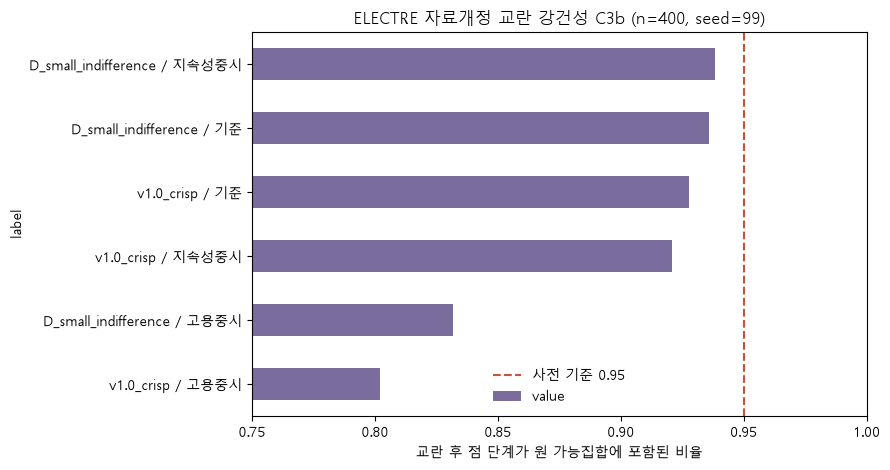

0.95 이상 통과: 0 / 6 개 조합 | 최댓값: 0.938359


#### LIM1

- **statement:** 점 배정은 입력자료 개정 교란에 대해 합격선을 충족하지 못한다. g2의 b1 경계값 2.0%p는 고용 자료 개정폭 90분위 1.944%p와 거의 같은 크기이며(비율 1.029), 판별표본 89행 중 67.4%가 어떤 기준에서든 경계까지의 거리가 개정폭 90분위 안에 있다. Phase 4에서 시도한 18개 조합 전부가 미달했고 최댓값은 0.935였다. 이는 파라미터 선택의 문제가 아니라 경계값과 자료 개정폭의 크기 관계에서 오는 구조적 제약이다.

#### LIM2

- **statement:** 구간 배정 산출물은 사전등록한 I3(교란 후 점 단계가 가능 단계 집합에 포함되는 비율, 임계 0.95)를 충족하지 못했다(실측 0.893). I3는 자료 불확실성과 파라미터 불확실성을 결합한 지표이며, 가능 단계 집합이 좁을수록 값이 낮아지는 구조를 갖는다(평균 가능 단계 수 1.294). 두 불확실성을 분리해 자료 교란 하의 가능 집합 안정성만 측정한 C3c는 판별표본 0.930, 전체 0.948로 임계 0.90을 충족했다. 합격선을 낮추지 않았으며 최종 판정은 INTERVAL_BLOCKED_BY_I3로 유지한다.

In [9]:
c3b = robust.loc[robust.metric_id.eq('C3b')].copy()
c3b['label'] = c3b.model_id + ' / ' + c3b.scenario_id
show_table(c3b[['label', 'value', 'threshold', 'pass', 'n_replicates', 'seed']])

ax = c3b.sort_values('value').plot.barh(x='label', y='value', legend=False, color='#7A6C9D', figsize=(9, 4.8))
ax.axvline(.95, color='#C5523F', ls='--', label='사전 기준 0.95')
ax.set_xlim(.75, 1)
ax.set_xlabel('교란 후 점 단계가 원 가능집합에 포함된 비율')
ax.set_title('ELECTRE 자료개정 교란 강건성 C3b (n=400, seed=99)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print('0.95 이상 통과:', int(c3b['pass'].sum()), '/', len(c3b), '개 조합 | 최댓값:', round(c3b.value.max(), 6))
show_records(limitations, 'limitation_id', ['statement'])

### 관찰 결과

- C3b는 6개 조합(v1.0_crisp·D_small_indifference × 3개 시나리오) 모두 사전 기준 0.95에 미달했다. 값은 0.802234~0.938359이고, 최댓값은 D_small_indifference/지속성중시의 0.938359다.
- LIM1: g2의 b1 경계값 2.0%p가 고용 자료 개정폭 90분위(1.944%p)와 거의 같은 크기(비율 1.029)이고, 판별표본 89행 중 67.4%가 어떤 기준에서든 경계까지의 거리가 개정폭 90분위 안에 있다.
- LIM2: 자료 불확실성과 파라미터 불확실성을 결합한 I3는 0.893으로 미달하지만, 자료 교란만 분리한 C3c는 판별표본 0.930·전체 0.948로 0.90 기준을 충족한다.

### 최종 설계에 미친 영향

점 배정 단일값은 실측 자료개정 규모만큼의 흔들림에도 취약하다는 것이 확인됐다. 이 결과는 ELECTRE를 전체 자동판정이 아니라 추가확인군의 선택적 재검토로 한정하는 근거 중 하나가 됐다.

## C. SMAA-TRI 파라미터 불확실성

### 무엇을 확인하려 했나

weight·lambda·p/q를 하나의 값으로 고정하지 않고, 사전 등록한 파라미터 공간에서 표집해 배정이 얼마나 유지되는지 확인한다.

이 결과는 `outputs/final_model/03_electre_smaa/tables/{electre_smaa_review_cases,electre_smaa_summary}.csv`에 저장된 실행 산출물이다. 코드는 `logs/experiments/electre_mrsort/src/model/robust.py`이다.

In [10]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'robust.py', 19, 50)

`logs/experiments/electre_mrsort/src/model/robust.py:19-50`

```python
def sample_parameter_space(prereg_doc, rng):
    """사전등록 parameter_space에서 (weights, lambda, p, q) n_samples개를 표집한다.

    w ~ Dirichlet(1,1,1,1)에서 각 w_j가 [min,max] 안에 들 때까지 기각 재추출.
    lambda ~ U(min,max). p_j ~ U(0, p_upper_j). q_j ~ U(0, p_j/2)(항상 q_j <= p_j/2 <= p_j
    이므로 0<=q<=p pseudo-criterion 제약을 자동으로 만족한다).
    seed는 이 함수가 스스로 정하지 않는다 — 호출자가 prereg_doc['parameter_space']['seed']로
    만든 rng를 넘긴다.
    반환: [{'weights': {...}, 'lambda': float, 'p': {...}, 'q': {...}}, ...] 길이 n_samples.
    """
    ps = prereg_doc['parameter_space']
    crit = config.CRITERIA
    lam_min, lam_max = float(ps['lambda']['min']), float(ps['lambda']['max'])
    w_min, w_max = float(ps['weights']['min']), float(ps['weights']['max'])
    p_upper = ps['p_upper']
    n_samples = int(ps['n_samples'])

    samples = []
    for _ in range(n_samples):
        for attempt in range(_MAX_REJECTION_ATTEMPTS):
            w = rng.dirichlet(np.ones(len(crit)))
            if np.all(w >= w_min) and np.all(w <= w_max):
                break
        else:
            raise RuntimeError(
                f'{_MAX_REJECTION_ATTEMPTS}회 시도해도 [{w_min},{w_max}] 안의 가중치를 뽑지 못했습니다.')
        lam = float(rng.uniform(lam_min, lam_max))
        p = {j: float(rng.uniform(0.0, float(p_upper[j]))) for j in crit}
        q = {j: float(rng.uniform(0.0, p[j] / 2.0)) for j in crit}
        samples.append({'weights': dict(zip(crit, map(float, w))), 'lambda': lam, 'p': p, 'q': q})
    return samples

```

In [11]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'robust.py', 52, 88)

`logs/experiments/electre_mrsort/src/model/robust.py:52-88`

```python
def assignment_matrix(values, scenario_profiles, samples, gate=True, veto=None):
    """(n_samples, n_rows) 판정단계 행렬. 비관적 배정(공식 모형의 할당 절차)을 쓴다.

    scenario_profiles : {'b1': {...}, 'b2': {...}} — 표집하지 않는 경계 프로파일(고정).
    gate : require_employment_evidence.
    저장은 int8 코드(0=OBSERVE,1=CHECK,2=PRIORITY,-1=UNDETERMINED)로 한다(메모리 절약).
    """
    crit = config.CRITERIA
    n_rows = len(values)
    scorable = values[list(crit)].notna().all(axis=1).to_numpy()
    matrix = np.full((len(samples), n_rows), -1, dtype=np.int8)
    if veto is None and samples:
        # Same inequalities as forward_outranks, batched to bound memory use.
        # Independent audit compared every cell with the original implementation.
        x = values[list(crit)].to_numpy(dtype=float)
        for start in range(0, len(samples), 1000):
            batch = samples[start:start + 1000]
            w = np.array([[s['weights'][j] for j in crit] for s in batch])
            q = np.array([[s['q'][j] for j in crit] for s in batch])
            p = np.array([[s['p'][j] for j in crit] for s in batch])
            if np.any(q < 0) or np.any(p < q):
                raise ValueError('0 <= q <= p 조건을 충족해야 합니다.')
            lam = np.array([s['lambda'] for s in batch])
            stage = np.zeros((len(batch), n_rows), dtype=np.int8)
            for rank, boundary in enumerate(('b1', 'b2'), 1):
                b = np.array([scenario_profiles[boundary][j] for j in crit])
                den = p - q
                c = np.clip((x[None] - (b-p)[:, None]) / np.where(den == 0, 1, den)[:, None], 0, 1)
                c = np.where((den == 0)[:, None], x[None] >= (b-q)[:, None], c)
                c = np.nan_to_num(c)
                passed = (c * w[:, None]).sum(axis=2) >= lam[:, None] - electre.EPS
                if gate:
                    passed &= (c[:, :, [0, 1, 3]] > 0).any(axis=2)
                stage[passed & scorable[None]] = rank
            stage[:, ~scorable] = -1
            matrix[start:start + len(batch)] = stage
        return matrix
```

In [12]:
show_source(ELECTRE_MRSORT_MODEL_DIR / 'robust.py', 127, 137)

`logs/experiments/electre_mrsort/src/model/robust.py:127-137`

```python
def class_acceptability(matrix, row_keys):
    """행별 등급수용지수(CAI): 각 단계가 표집에서 선택된 비율. 행 합은 정확히 1이다."""
    n_samples, n_rows = matrix.shape
    rows = []
    for j in range(n_rows):
        col = matrix[:, j]
        cai = {code: float(np.sum(col == code)) / n_samples for code in (0, 1, 2, -1)}
        rows.append({'industry': row_keys['industry'].iat[j], 'quarter': row_keys['quarter'].iat[j],
                     'cai_observe': cai[0], 'cai_check': cai[1], 'cai_priority': cai[2],
                     'cai_undetermined': cai[-1]})
    return pd.DataFrame(rows)
```

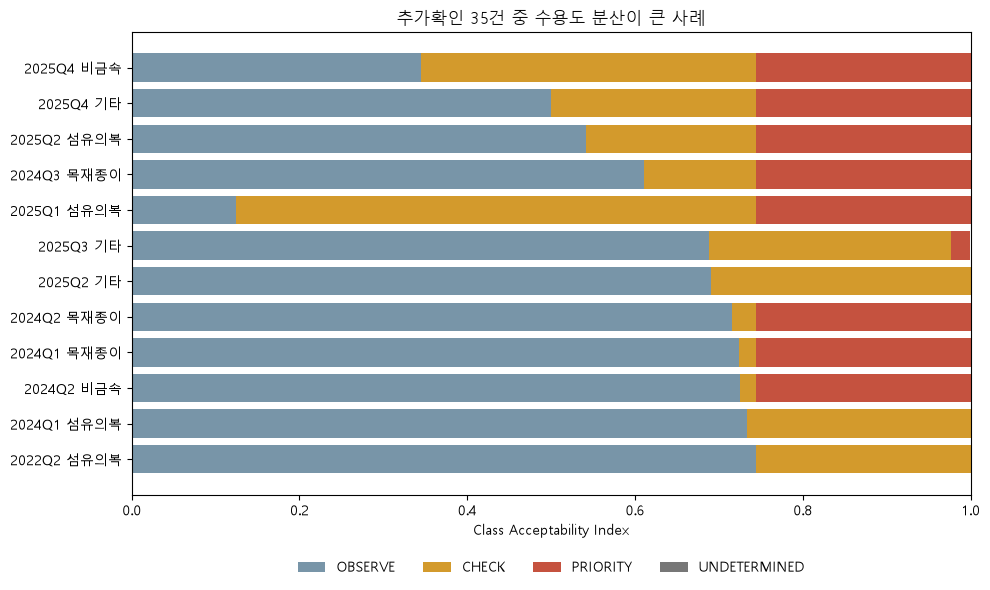

| review_queue_group | electre_stage | smaa_parameter_sensitive | case_count |
| --- | --- | --- | --- |
| 1 자료·모형 불확실 확인 | UNDETERMINED | False | 4 |
| 2 Triage-ELECTRE 불일치 확인 | OBSERVE | True | 2 |
| 3 파라미터 민감 우선검토 후보 | PRIORITY | True | 19 |
| 4 안정 우선검토 후보 | PRIORITY | False | 1 |
| 5 파라미터 민감 추가확인 | CHECK | True | 8 |
| 6 추가확인 | CHECK | False | 1 |

가능단계 2개 이상: 29 / 35 | necessary_stage 결측(단일 필연단계 없음): 29 | smaa_parameter_sensitive: 29


In [13]:
cai_cols = ['cai_observe', 'cai_check', 'cai_priority', 'cai_undetermined']
u = review.copy()
u['uncertainty'] = 1 - u[cai_cols].max(axis=1)
u_top = u.nlargest(12, 'uncertainty').sort_values('uncertainty')
labels = u_top['quarter'] + ' ' + u_top['industry']
left = np.zeros(len(u_top))
fig, ax = plt.subplots(figsize=(10, 6))
for c, color, name in zip(cai_cols, ['#7895A8', '#D39A2C', '#C5523F', '#777777'],
                           ['OBSERVE', 'CHECK', 'PRIORITY', 'UNDETERMINED']):
    ax.barh(labels, u_top[c], left=left, label=name, color=color)
    left += u_top[c].to_numpy()
ax.set_xlim(0, 1)
ax.set_xlabel('Class Acceptability Index')
ax.set_title('추가확인 35건 중 수용도 분산이 큰 사례')
ax.legend(frameon=False, ncol=4, loc='lower center', bbox_to_anchor=(.5, -.2))
plt.tight_layout(); plt.show()

show_table(smaa_summary)
print('가능단계 2개 이상:', int(review.n_possible.ge(2).sum()), '/', len(review),
      '| necessary_stage 결측(단일 필연단계 없음):', int(review.necessary_stage.isna().sum()),
      '| smaa_parameter_sensitive:', int(review.smaa_parameter_sensitive.sum()))

### 관찰 결과

- 추가확인 35건 중 29건은 파라미터 표집 공간에서 가능단계가 2개 이상이고, 그만큼 29건은 단일 필연 배정(necessary_stage)이 없다.
- `smaa_parameter_sensitive=True`도 29건으로 같은 집합이다.
- `electre_smaa_summary.csv` 기준 35건의 ELECTRE 단일 배정 결과는 PRIORITY 20건·CHECK 9건·UNDETERMINED 4건·OBSERVE 2건으로 나뉘며, `boundary_action`을 보면 어느 것도 Triage 단계를 자동으로 올리거나 내리지 않는다.

### 최종 설계에 미친 영향

SMAA는 정답 weight나 위기확률을 주지 않는다. 추가확인군 내부에서 파라미터에 민감한 사례를 표시해 검토 순서를 매기는 용도로만 쓴다.

## D. 독립 감사

### 무엇을 확인하려 했나

ELECTRE/SMAA 구현과 표집설계, 자료개정 교란 방식에 대한 독립 감사가 이전 지적사항을 어떻게 재검증했고 어떤 조치를 남겼는지 확인한다.

이 결과는 `logs/validation/audits/independent_audit/{REPORT.md,findings.csv,summary.json}`에 저장된 실행 산출물이다.

In [14]:
report_text = (AUDIT_DIR / 'REPORT.md').read_text(encoding='utf-8')
exec_summary = report_text.split('## ①', 1)[1].split('## ②', 1)[0]
print(exec_summary.strip())

Executive Summary

최종 판단: **HYBRID**. Q1 상태·Q2 규모·Q3 시간과 명시적인 후속 확인 질문을 운영 출력의 중심에 두고, ELECTRE 계열은 연구진 규범에 조건부인 배정/민감도 층으로 유지한다. 단일 등급 자동 우선순위나 정책 승인 모형으로 채택하지 않는다. 단순 규칙으로 바꾸면 문제가 해결된다는 증거도 없다.

1. 원자료→마스터→국면 패널 5종이 재현됐고, 기존 핵심 수치도 재현됐다. 수정 전 테스트는 **277 passed, 2 skipped**다.
2. I3는 최종 양립공간 밖의 고정 파라미터까지 평가했다. 무교란에서도 고용중시 crisp 포함률은 **0.85**다. 기존 Jaccard는 **무제약 공간**의 수치다. 따라서 서로 다른 집합을 비교한 기존 판정은 운영 적합성의 종합 증거가 될 수 없다.
3. 교란은 g를 독립적으로 흔든 것이 아니라 원 수준을 흔들었지만, 같은 분기의 원값과 lag에 다른 개정을 적용했다. 이를 고치고 **비교 가능한 과거 고용 이력**으로 g4를 계산하니 **40행**의 지속기간이 바뀌었다. 재분류 위험 기간에서 런을 끊고 Q1 상태는 보존했다.
4. 개정 pool의 큰 고용 수정은 알려진 **2024Q3 원파일 오류 정정**에 집중됐다. 이를 제외한 시나리오에서 유지율은 0.990~0.993이지만, 표본이 부족해 일반적인 안정성을 입증하지 못한다. 오류 정정을 포함한 스트레스도 함께 남겼다.
5. 연속공간 외부범위 LP와 실제 feasible witness로 **154/160행**의 집합을 확인했다(수치 허용오차 조건). **6행**은 미해결로 남겼다. 기존 표본이 놓친 배정 **5건**이 있어 ‘표본 공통=필연’은 실제로 틀렸다.

새 합격선을 만들어 통과시키지 않았다. legacy `INTERVAL_BLOCKED_BY_I3` 기록은 보존한다. HYBRID는 수정된 도구의 구조에 대한 판단이며, legacy 기준 통과 또는 현장 정책효과 입증 선언이 아니다.


In [15]:
show_table(audit_findings)
print('판정 분포:', audit_findings['판정'].value_counts().to_dict())
print('연속공간 인증:', audit_summary['continuous_certified_rows'], '/',
      audit_summary['continuous_certified_rows'] + audit_summary['continuous_unresolved_rows'], '행',
      '| 표본이 놓친 가능배정:', audit_summary['sample_missed_categories'], '건',
      '| g4(지속기간) 재계산으로 바뀐 행:', audit_summary['history_g4_changed_rows'], '건')

| 지적 | 판정 | 구분 | 심각도 | 근거 | 파일 |
| --- | --- | --- | --- | --- | --- |
| RC/VRC 독립성 | CONFIRMED | 검증설계 | 중대 | prereg AM3·AM4·AM6의 선행 결과 인지 기록. 다만 작성자의 인지 상태와 실제 등록 시각은 파일만으로 독립 검증 불가. | config/model_revalidation_prereg.yaml; baseline/snapshot |
| VRC4 단일 규범 의존 | CONFIRMED | 정책선호 | 중대 | 양립 표본 1745→447. 지속 2·3·4분기 모두 899/6000 통과로 동일. | parameter_spaces.csv; summary.json |
| 합격선의 운영 근거 | PARTIALLY_CONFIRMED | 검증설계 | 중대 | 합격선·개정 이력은 명시. 실제 담당자 비용·점검 용량에 따른 도출 근거 없음. | config/model_revalidation_prereg.yaml |
| I3/Jaccard 정합 | CONFIRMED | 구현/평가대상 | 치명적 | I3 고정 6조합 일부는 양립공간 밖. C3c는 무제약 1000표본. 같은 최종 구간 검증으로 취급할 수 없음. | i3_zero_noise.csv; src/model/revalidation_phase5.py |
| 필연배정 명칭 | CONFIRMED | 추론 | 치명적 | 표본 공통 배정을 필연/확정으로 표기. 실제 feasible witness가 표본 누락 배정 5건을 확인. | continuous_space_certificates.csv; feasible_witnesses.json |
| MRSort 추가 효용 부재 | PARTIALLY_CONFIRMED | 방법선택 | 중대 | count2와 실제 차이는 2/160행. 다만 중요성을 판정할 현장 정답은 없으므로 무용함까지 입증되지 않음. | alternative_changed_cases.csv |
| g1·g2·g4 중복 | PARTIALLY_CONFIRMED | 지표설계 | 중대 | 공통 원계열이나 각각 배정을 바꾸는 행 존재. 규모/강도/지속 차원이 완전히 동일하지 않음. | criterion_decision_effects.csv |
| 교란의 비현실성 | PARTIALLY_CONFIRMED | 구현/자료생성 | 중대 | g 자체 독립교란은 아님. 원 수준과 lag의 독립 복원추출로 같은 분기 두 값이 불일치. 원파일 오류 정정이 pool에 혼입. | src/model/perturb.py; vintage_by_quarter.csv |
| 기존 예측 검증의 과장 | CONFIRMED | 해석 | 중대 | 관측된 Spearman 차이로 원리적 열위·모든 파라미터 불가능을 선언. 해당 전체 명제는 입증되지 않음. | config/model_revalidation_prereg.yaml invalidated_gates |
| 180행을 모두 독립 취급 | NOT_CONFIRMED | 검증설계 | — | 업종 군집 bootstrap·업종 leave-out이 이미 존재. 다만 기존 교란에는 시간/업종 결합구조가 없음. | src/model/resample.py; revision_by_period.csv; revision_leave_industry_out.csv |
| 등급과 점검순서 불일치 | PARTIALLY_CONFIRMED | 운영 | 중대 | 후속 질문·UNDETERMINED 라우팅은 기존에 존재. 실제 담당자·용량·동률 처리 승인과 현장 효용 검증은 없음. | src/model/stage_actions.py; action_latest.csv |
| 설명비용/공모전 감점 | CANNOT_VERIFY | 외적평가 | — | 실제 심사위원 이해도나 감점은 저장소에서 검증할 수 없음. 연구용 부록과 운영 출력 분리는 가능. | REPORT.md 최종 구조 |
| 고용 게이트 효과 | NOT_CONFIRMED | 인과 설명 | 중대 | 6000×180 배정에서 gate 제거 변화 0. 고정 관찰의 원인을 게이트로 단독 귀속할 수 없음. | summary.json gate_changes |
| g2·g3 단위 오류 | PARTIALLY_CONFIRMED | 문서 | 경미 | 산식·config 표시 단위는 %로 맞음. prereg 일부 rationale과 전달 문구에 %p 혼용. 등록 원문은 보존하고 해석 정정. | src/model/config.py; config/model_revalidation_prereg.yaml |

판정 분포: {'PARTIALLY_CONFIRMED': 6, 'CONFIRMED': 5, 'NOT_CONFIRMED': 2, 'CANNOT_VERIFY': 1}
연속공간 인증: 154 / 160 행 | 표본이 놓친 가능배정: 5 건 | g4(지속기간) 재계산으로 바뀐 행: 40 건


### 관찰 결과

- 독립 감사의 최종 판단은 HYBRID다. 단일 등급 자동 우선순위나 정책 승인 모형으로 채택하지 않는다.
- 14개 이전 지적 중 판정은 CONFIRMED 5건, PARTIALLY_CONFIRMED 6건, NOT_CONFIRMED 2건, CANNOT_VERIFY 1건이다.
- 연속공간 외부범위를 LP와 feasible witness로 154/160행까지 확인했고 6행은 미해결로 남겼다. 기존 표본이 놓친 가능 배정이 5건 있어 "표본 공통 배정=필연"이라는 이전 명칭이 CONFIRMED로 지적됐다.
- g4(비교 가능한 고용 하회 지속기간)를 다시 계산하니 40행의 값이 바뀌었다.

### 최종 설계에 미친 영향

RC/VRC 독립성, 표본 공통 배정의 명칭 문제 등은 CONFIRMED로 남았다. 이 결과는 ELECTRE/SMAA를 전체 자동판정이 아니라 연구진 규범에 조건부인 배정·민감도 층으로 유지하는 근거가 됐다.

## E. Triage 민감도·ablation — 이 파트는 노트북에서 직접 재실행한다

### 무엇을 확인하려 했나

Triage도 운영 threshold에 의존한다. `src/triage/run_triage.py`가 실제로 호출하는 순서(`compute_axes` → 원본 state 병합 → `apply_rule` → 기간창)를 그대로 재현해 baseline을 다시 만들고, `src/triage/triage_audit.py`가 정의한 15개 변형 사양을 baseline과 비교한다. 저장된 `logs/validation/triage/sensitivity_own_rules.csv`와 값이 같은지도 이 노트북 안에서 직접 대조한다.

In [16]:
show_source(config.ROOT / 'src/triage/triage_rule.py', 18, 28)

`src/triage/triage_rule.py:18-28`

```python
RULE_VERSION = 'changwon-triage-rule/3.1.0-audited'

# ---------------------------------------------------------------- 경계값
LEVEL_ENTRY = 5.0    # PRINCIPLE_ADAPTED: 피보험자·이동평균과 KICOX 분기말 고용은 다름
LEVEL_UP = 10.0      # PRINCIPLE_ADAPTED: 법정 지역 지정이 아닌 내부 업종 점검
REL_ENTRY = 5.0      # PRINCIPLE: 특별고용지원업종 제2조①1호(전국평균 대비 5%p) → 산단 제조업 평균 대비
REL_UP = 10.0        # OWN: 조문에 상위 %p 기준 없음
ABS_ENTRY = 1.0      # OWN: 고용 감소인원 ÷ 산단 제조업 고용
ABS_UP = 2.0         # OWN
PROD_SUPPORT = 5.0   # PRINCIPLE: 선제대응 제2조③3호 생산액 5%
SCALE_MIN = 300      # PRINCIPLE: 선제대응 제2조①2호 '종사자 300인 이상' → 우선점검 진입요건으로만
```

In [17]:
show_source(config.ROOT / 'src/triage/triage_rule.py', 95, 99)

`src/triage/triage_rule.py:95-99`

```python
def apply_rule(df: pd.DataFrame, *, level_entry=LEVEL_ENTRY, level_up=LEVEL_UP,
               rel_entry=REL_ENTRY, rel_up=REL_UP, abs_entry=ABS_ENTRY, abs_up=ABS_UP,
               prod_support=PROD_SUPPORT, scale_min=SCALE_MIN,
               use_persist=True, use_prod=True, gate='priority_gate',
               missing_policy='partial') -> pd.DataFrame:
```

In [18]:
from triage import triage_rule as tr

show_source(tr.compute_axes)

`src/triage/triage_rule.py:56`

```python
def compute_axes(master: pd.DataFrame) -> pd.DataFrame:
    """industry master에서 5개 축의 원값을 만든다. 결측 보간 없음."""
    m = master.copy()
    m.columns = [c.lstrip('﻿') for c in m.columns]
    m = m.sort_values(['industry', 'quarter']).reset_index(drop=True)
    if m.duplicated(['industry', 'quarter']).any():
        raise ValueError('Duplicate industry-quarter')
    if (m[['employment','production']] < 0).any().any():
        raise ValueError('Negative raw level')
    # Calendar joins must not bridge a missing quarter.
    lag = m[['industry','quarter','employment','production']].copy()
    lag['quarter'] = (pd.PeriodIndex(lag.quarter, freq='Q') + 4).astype(str)
    lag = lag.rename(columns={'employment':'employment_lag4','production':'production_lag4'})
    m = m.merge(lag,on=['industry','quarter'],how='left',validate='one_to_one')
    m['emp_delta'] = m['employment'] - m['employment_lag4']
    m['e_yoy'] = (m['employment'] / m['employment_lag4'] - 1) * 100
    m['p_yoy'] = (m['production'] / m['production_lag4'] - 1) * 100
    m[['e_yoy', 'p_yoy']] = m[['e_yoy', 'p_yoy']].replace([np.inf, -np.inf], np.nan)
    # 산단 10개 제조업종 합계 기준 YoY (비제조 포함 total master는 쓰지 않는다)
    tot = m.groupby('quarter')['employment'].sum(min_count=10)
    m['mfg_emp'] = m['quarter'].map(tot)
    prev_tot = tot.copy()
    prev_tot.index = (pd.PeriodIndex(prev_tot.index,freq='Q')+4).astype(str)
    m['mfg_emp_lag4'] = m['quarter'].map(prev_tot)
    m['mfg_emp_yoy'] = (m['mfg_emp'] / m['mfg_emp_lag4'] - 1) * 100
    m['E'] = np.maximum(0.0, -m['e_yoy'])
    m['P'] = np.maximum(0.0, -m['p_yoy'])
    m['R'] = np.maximum(0.0, -(m['e_yoy'] - m['mfg_emp_yoy']))
    m['A'] = (-m['emp_delta']).clip(lower=0) / m['mfg_emp'].where(m['mfg_emp'] > 0) * 100
    for c in ['E','R','A','P']:
        m.loc[m[c].eq(0),c] = 0.0
    m['employment_share_pct'] = m['employment'] / m['mfg_emp'] * 100
    m['mfg_emp_delta'] = m['mfg_emp'] - m['mfg_emp_lag4']
    gross = m.groupby('quarter')['emp_delta'].agg(lambda x: x.abs().sum(min_count=10))
    m['net_gross_ratio'] = m['mfg_emp_delta'].abs()/m.quarter.map(gross)
    m['contribution_pct'] = (m.emp_delta/m.mfg_emp_delta*100).where(m.net_gross_ratio >= .30)
    return m

```

In [19]:
show_source(config.ROOT / 'src/triage/run_triage.py', 21, 28)

`src/triage/run_triage.py:21-28`

```python
def sha(p): return hashlib.sha256(Path(p).read_bytes()).hexdigest()
def save(df,name): df.to_csv(OUT/name,index=False,encoding='utf-8-sig')
def window(d): return d[d.quarter.between(W0,W1)].copy()
def load(master=MASTER,state=STATE):
    m=tr.compute_axes(pd.read_csv(master))
    p=pd.read_csv(state)
    keep=['industry','quarter','state','run_length','transition_type','previous_state','production_yoy_reason','production_current_missing','production_lag4_missing','employment_yoy_reason']
    return m.merge(p[keep],on=['industry','quarter'],how='left',validate='one_to_one')
```

### 재실행 1단계 — baseline 재구성

`run_triage.py`의 `load()`와 같은 순서로 `changwon_industry_master.csv`를 `compute_axes`에 넣고, `changwon_state_panel.csv`의 일부 열을 병합한 뒤 `apply_rule`을 기본 파라미터로 실행하고 2022Q1~2026Q2로 창을 자른다.

In [20]:
MASTER_PATH = config.ROOT / 'data/processed/kicox/changwon_industry_master.csv'
STATE_PATH = config.ROOT / 'data/processed/kicox/changwon_state_panel.csv'
W0, W1 = '2022Q1', '2026Q2'

def window(d):
    return d[d.quarter.between(W0, W1)].copy()

def canonical(d):
    return d.sort_values(['industry', 'quarter']).reset_index(drop=True)

master_axes = tr.compute_axes(pd.read_csv(MASTER_PATH))
state_cols = ['industry', 'quarter', 'state', 'run_length', 'transition_type', 'previous_state',
              'production_yoy_reason', 'production_current_missing', 'production_lag4_missing',
              'employment_yoy_reason']
state_panel = pd.read_csv(STATE_PATH)
base = master_axes.merge(state_panel[state_cols], on=['industry', 'quarter'], how='left', validate='one_to_one')

baseline = canonical(window(tr.apply_rule(base)))
print('재실행 baseline 행수:', len(baseline))
print(baseline.stage.value_counts().reindex(['우선점검', '추가확인', '관찰', '자료확인'], fill_value=0).to_string())

재실행 baseline 행수: 180
stage
우선점검     17
추가확인     35
관찰      128
자료확인      0


### 재실행 2단계 — 15개 변형 사양

`triage_audit.py`가 정의한 `variants` dict을 그대로 옮겨 각 사양으로 `apply_rule`을 다시 호출하고, baseline과 stage가 달라진 행 수·우선점검 여부가 바뀐 행 수·최신분기 변경 행 수를 집계한다.

In [21]:
variants = {
    'A 0.5/1': dict(abs_entry=.5, abs_up=1),
    'A 1/2': {},
    'A 2/4': dict(abs_entry=2, abs_up=4),
    'A 제거': dict(abs_entry=np.inf, abs_up=np.inf),
    '규모 200': dict(scale_min=200),
    '규모 300': {},
    '규모 500': dict(scale_min=500),
    '규모 1000': dict(scale_min=1000),
    'gate 없음': dict(gate='none'),
    'hard exclusion': dict(gate='hard'),
    'flag 정렬만': dict(gate='flag'),
    'Q3 제거': dict(use_persist=False),
    'P 제거': dict(use_prod=False),
    '완전 자료확인': dict(missing_policy='complete'),
    'R 상위 제거': dict(rel_up=np.inf),
}  # src/triage/triage_audit.py의 variants dict과 동일

variant_frames = {}
own_rows = []
for label, kw in variants.items():
    v = canonical(window(tr.apply_rule(base, **kw)))
    variant_frames[label] = v
    changed = baseline.stage.ne(v.stage)
    priority_changed = baseline.stage.eq('우선점검').ne(v.stage.eq('우선점검'))
    latest_changed = changed & baseline.quarter.eq(baseline.quarter.max())
    counts = v.stage.value_counts()
    own_rows.append({
        'variant': label,
        'changed_rows': int(changed.sum()),
        'priority_changed_rows': int(priority_changed.sum()),
        'latest_changed_rows': int(latest_changed.sum()),
        **{s: int(counts.get(s, 0)) for s in tr.STAGES + ('규모미달',)},
    })
own_summary = pd.DataFrame(own_rows)
show_table(own_summary)

| variant | changed_rows | priority_changed_rows | latest_changed_rows | 우선점검 | 추가확인 | 관찰 | 자료확인 | 규모미달 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A 0.5/1 | 5 | 2 | 0 | 19 | 36 | 125 | 0 | 0 |
| A 1/2 | 0 | 0 | 0 | 17 | 35 | 128 | 0 | 0 |
| A 2/4 | 6 | 6 | 1 | 11 | 41 | 128 | 0 | 0 |
| A 제거 | 9 | 9 | 1 | 8 | 40 | 132 | 0 | 0 |
| 규모 200 | 4 | 4 | 0 | 21 | 31 | 128 | 0 | 0 |
| 규모 300 | 0 | 0 | 0 | 17 | 35 | 128 | 0 | 0 |
| 규모 500 | 2 | 2 | 1 | 15 | 37 | 128 | 0 | 0 |
| 규모 1000 | 8 | 8 | 1 | 9 | 43 | 128 | 0 | 0 |
| gate 없음 | 24 | 24 | 0 | 41 | 11 | 128 | 0 | 0 |
| hard exclusion | 66 | 0 | 3 | 17 | 4 | 93 | 0 | 66 |
| flag 정렬만 | 24 | 24 | 0 | 41 | 11 | 128 | 0 | 0 |
| Q3 제거 | 8 | 8 | 0 | 9 | 43 | 128 | 0 | 0 |
| P 제거 | 4 | 4 | 1 | 13 | 39 | 128 | 0 | 0 |
| 완전 자료확인 | 20 | 1 | 0 | 16 | 31 | 113 | 20 | 0 |
| R 상위 제거 | 1 | 1 | 0 | 16 | 36 | 128 | 0 | 0 |

### 재실행 3단계 — 저장된 민감도 표와 대조

노트북에서 방금 계산한 `own_summary`와 저장된 `logs/validation/triage/sensitivity_own_rules.csv`를 사양별로 맞춰, 변경행 수·우선점검 변경행 수·최신분기 변경행 수가 정확히 같은지 확인한다.

In [22]:
saved = sensitivity_saved.copy()
saved.columns = [c.lstrip('\ufeff') for c in saved.columns]
compare_cols = ['changed_rows', 'priority_changed_rows', 'latest_changed_rows']
merged = own_summary.merge(saved[['variant'] + compare_cols], on='variant', suffixes=('_재실행', '_저장본'))

mismatch_frames = []
for col in compare_cols:
    diff = merged[f'{col}_재실행'] != merged[f'{col}_저장본']
    if diff.any():
        mismatch_frames.append(merged.loc[diff, ['variant', f'{col}_재실행', f'{col}_저장본']])
n_mismatch = sum(len(x) for x in mismatch_frames)

show_table(merged[['variant'] + [f'{c}_{s}' for c in compare_cols for s in ('재실행', '저장본')]])
print('비교한 사양 수:', len(merged), '| 불일치 셀 수:', n_mismatch)
print('baseline 행수 일치(180):', len(baseline) == 180,
      '| baseline stage 분포 일치(관찰128/추가확인35/우선점검17):',
      baseline.stage.value_counts().to_dict() == {'관찰': 128, '추가확인': 35, '우선점검': 17})

| variant | changed_rows_재실행 | changed_rows_저장본 | priority_changed_rows_재실행 | priority_changed_rows_저장본 | latest_changed_rows_재실행 | latest_changed_rows_저장본 |
| --- | --- | --- | --- | --- | --- | --- |
| A 0.5/1 | 5 | 5 | 2 | 2 | 0 | 0 |
| A 1/2 | 0 | 0 | 0 | 0 | 0 | 0 |
| A 2/4 | 6 | 6 | 6 | 6 | 1 | 1 |
| A 제거 | 9 | 9 | 9 | 9 | 1 | 1 |
| 규모 200 | 4 | 4 | 4 | 4 | 0 | 0 |
| 규모 300 | 0 | 0 | 0 | 0 | 0 | 0 |
| 규모 500 | 2 | 2 | 2 | 2 | 1 | 1 |
| 규모 1000 | 8 | 8 | 8 | 8 | 1 | 1 |
| gate 없음 | 24 | 24 | 24 | 24 | 0 | 0 |
| hard exclusion | 66 | 66 | 0 | 0 | 3 | 3 |
| flag 정렬만 | 24 | 24 | 24 | 24 | 0 | 0 |
| Q3 제거 | 8 | 8 | 8 | 8 | 0 | 0 |
| P 제거 | 4 | 4 | 4 | 4 | 1 | 1 |
| 완전 자료확인 | 20 | 20 | 1 | 1 | 0 | 0 |
| R 상위 제거 | 1 | 1 | 1 | 1 | 0 | 0 |

비교한 사양 수: 15 | 불일치 셀 수: 0
baseline 행수 일치(180): True | baseline stage 분포 일치(관찰128/추가확인35/우선점검17): True


### 관찰 결과 (재실행)

- 재실행 baseline은 180행이고 관찰 128 / 추가확인 35 / 우선점검 17로, 저장된 `triage_panel.csv`와 같다.
- 15개 변형 사양 전부에서 `changed_rows`·`priority_changed_rows`·`latest_changed_rows`가 저장된 `sensitivity_own_rules.csv`와 셀 단위로 정확히 일치했다(불일치 0건).
- gate를 없애면(`gate 없음`) 24행이 바뀌고, hard exclusion은 66행, Q3 제거는 8행, P 제거는 4행이 baseline과 달라진다. 규모 200/500/1000은 각각 4/2/8행이 바뀐다.

이 재실행은 이 노트북을 실행한 환경에서 직접 계산과 대조를 함께 수행했다. 저장된 CSV를 그대로 보여주기만 한 것이 아니라, `compute_axes`·`apply_rule`을 다시 불러와 baseline과 15개 사양을 새로 계산하고 그 값을 저장본과 맞춰본 것이다.

In [23]:
major = ['A 제거', '규모 1000', 'Q3 제거', 'P 제거', 'R 상위 제거']
base_priority = baseline.loc[baseline.stage.eq('우선점검'), ['industry', 'quarter']].copy()

lost_frames, sensitive_frames = [], []
for label in major:
    v = variant_frames[label]
    cmp = baseline[['industry', 'quarter', 'stage']].merge(
        v[['industry', 'quarter', 'stage']], on=['industry', 'quarter'], suffixes=('', '_variant'))
    cmp['changed'] = cmp.stage.ne(cmp.stage_variant)
    lost_frames.append(cmp.loc[cmp.stage.eq('우선점검') & ~cmp.stage_variant.eq('우선점검'), ['industry', 'quarter']])
    sensitive_frames.append(cmp.loc[cmp.changed, ['industry', 'quarter', 'stage', 'stage_variant']].assign(variant=label))

lost_all = pd.concat(lost_frames).drop_duplicates() if lost_frames else pd.DataFrame(columns=['industry', 'quarter'])
stable = base_priority.merge(lost_all.assign(_lost=True), on=['industry', 'quarter'], how='left')
stable = stable.loc[stable._lost.isna(), ['industry', 'quarter']]
sensitive = pd.concat(sensitive_frames) if sensitive_frames else pd.DataFrame()

print(f'주요 5개 사양 모두에서 우선점검 유지(재실행): {len(stable)}/{len(base_priority)}건')
show_table(stable.sort_values(['quarter', 'industry']))
show_table(sensitive.head(25))

주요 5개 사양 모두에서 우선점검 유지(재실행): 0/17건


| industry | quarter |
| --- | --- |

| industry | quarter | stage | stage_variant | variant |
| --- | --- | --- | --- | --- |
| 기계 | 2022Q1 | 우선점검 | 관찰 | A 제거 |
| 기계 | 2022Q2 | 우선점검 | 관찰 | A 제거 |
| 기계 | 2022Q3 | 우선점검 | 관찰 | A 제거 |
| 기계 | 2022Q4 | 우선점검 | 관찰 | A 제거 |
| 기계 | 2023Q1 | 우선점검 | 추가확인 | A 제거 |
| 기계 | 2023Q2 | 우선점검 | 추가확인 | A 제거 |
| 기계 | 2023Q3 | 우선점검 | 추가확인 | A 제거 |
| 기계 | 2023Q4 | 우선점검 | 추가확인 | A 제거 |
| 기계 | 2026Q2 | 우선점검 | 추가확인 | A 제거 |
| 목재종이 | 2026Q1 | 우선점검 | 추가확인 | 규모 1000 |
| 목재종이 | 2026Q2 | 우선점검 | 추가확인 | 규모 1000 |
| 석유화학 | 2025Q2 | 우선점검 | 추가확인 | 규모 1000 |
| 음식료 | 2025Q1 | 우선점검 | 추가확인 | 규모 1000 |
| 음식료 | 2025Q2 | 우선점검 | 추가확인 | 규모 1000 |
| 음식료 | 2025Q3 | 우선점검 | 추가확인 | 규모 1000 |
| 음식료 | 2025Q4 | 우선점검 | 추가확인 | 규모 1000 |
| 음식료 | 2026Q1 | 우선점검 | 추가확인 | 규모 1000 |
| 기계 | 2022Q1 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2022Q2 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2022Q3 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2023Q1 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2023Q2 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2023Q3 | 우선점검 | 추가확인 | Q3 제거 |
| 기계 | 2023Q4 | 우선점검 | 추가확인 | Q3 제거 |
| 음식료 | 2026Q1 | 우선점검 | 추가확인 | Q3 제거 |

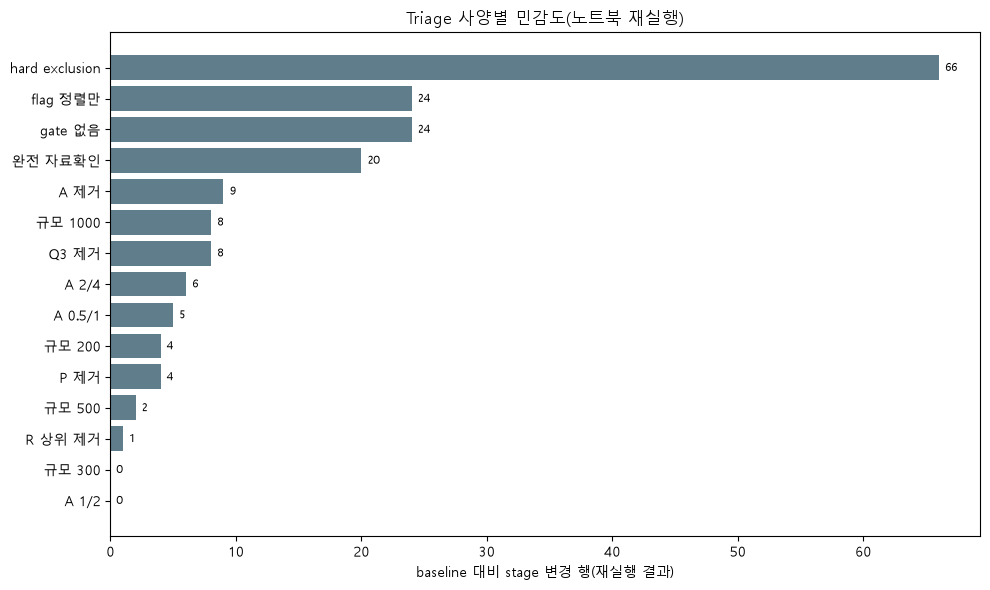

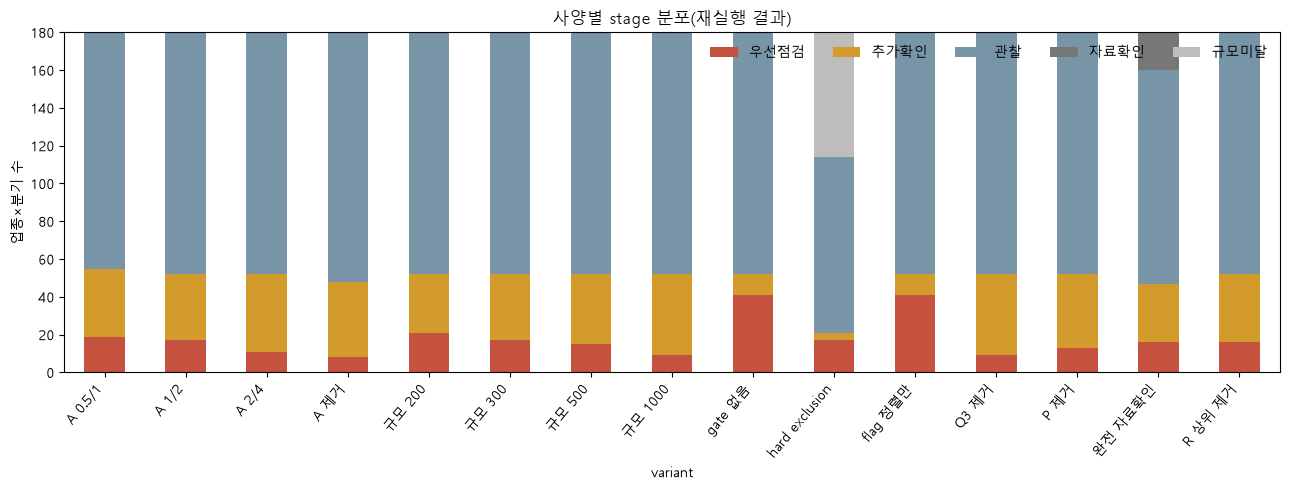

In [24]:
s = own_summary.copy().sort_values('changed_rows')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(s.variant, s.changed_rows, color='#607D8B')
for y, v in enumerate(s.changed_rows):
    ax.text(v + .5, y, str(int(v)), va='center', fontsize=8)
ax.set_xlabel('baseline 대비 stage 변경 행(재실행 결과)')
ax.set_title('Triage 사양별 민감도(노트북 재실행)')
plt.tight_layout(); plt.show()

stack = own_summary.set_index('variant')[['우선점검', '추가확인', '관찰', '자료확인', '규모미달']]
stack.plot.bar(stacked=True, figsize=(13, 5), color=['#C5523F', '#D39A2C', '#7895A8', '#777777', '#BDBDBD'])
plt.ylabel('업종×분기 수')
plt.title('사양별 stage 분포(재실행 결과)')
plt.xticks(rotation=50, ha='right')
plt.legend(frameon=False, ncol=5)
plt.tight_layout(); plt.show()

### 관찰 결과

- 규모 gate와 반복(Q3)·생산(P) 보강조건이 우선점검 진입을 실제로 제한한다. A 제거·규모 1000은 최신분기 결과도 각각 1건 바꾼다.
- 주요 5개 사양(A 제거·규모 1000·Q3 제거·P 제거·R 상위 제거) 중 어느 하나에서든 우선점검을 벗어나는 baseline 우선점검 17건 중 17건이 존재해, 5개 사양 모두에서 동시에 유지되는 사례는 0건이다. 기계·음식료가 여러 사양에 걸쳐 반복해서 걸린다.

### 해석

변경이 적다는 것과 그 기준이 옳다는 것은 다르다. 안정적으로 유지되는 사례도 현장 정답이 확인된 사례는 아니다.

> 주의: 이 재실행은 baseline이 저장본과 같다는 것과, 15개 변형 사양의 계산이 문서화된 로직과 정확히 같다는 것을 보여준다. 어느 사양이 "더 정확한지"는 이 재실행만으로 알 수 없다.

### Decision Box — 300인 gate(SCALE_MIN)를 왜 유지하는가

- **문제:** 상위신호와 보강신호를 모두 만족해도 업종 고용 규모가 작으면 그 변화가 산단 제조업 전체에서 차지하는 비중은 작다. `03_triage.ipynb`는 이 gate를 우선점검 진입에만 건다고 정했지만, 그 기준값 300이 결과를 얼마나 바꾸는지는 공개하지 않았다.
- **선택:** 이번 재실행에서도 `SCALE_MIN=300`을 그대로 유지한다. 200으로 낮추면 4행, 500으로 올리면 2행, 1000으로 올리면 8행이 baseline과 달라지고, gate 자체를 없애면 24행이 달라진다(hard exclusion은 66행).
- **근거:** 300 근방에서는 변경 폭이 상대적으로 작고(200/500 각각 4/2행), 1000까지 크게 올리거나 gate를 없애면 변경 폭이 급격히 커진다(8행, 24행). 이는 300이 "정답"이라는 근거가 아니라, 이 값 근방에서 결과가 급격히 흔들리지는 않는다는 관찰이다.
- **결론에 미친 영향:** 300인 gate는 최적화로 고른 값이 아니라 선제대응 제도(종사자 300인 이상)를 참고한 명시적 운영기준으로 남긴다. 기준을 바꿨을 때 실제로 몇 건이 바뀌는지는 이 표와 그림으로 그대로 공개한다.

## F. 시점 분리 검증(rolling / hybrid)

### 무엇을 확인하려 했나

확정된 사양(ELECTRE crisp, 최종 Triage)을 시점을 나눠 재구축한 과거 패널에 순차 적용했을 때, 사후적으로 나타난 추가 고용위축을 어떻게 갈랐는지 정리한다. 이는 신규 holdout 예측 성능 검증이 아니라, 같은 자료계열을 시간 순서로 다시 배열한 사후적 정합성 점검이다.

이 결과는 `logs/validation/outputs/{rolling_backtest,hybrid_validation}/*`에 저장된 실행 산출물이다. 코드는 `logs/validation/code/{run_temporal_validation.py,run_hybrid_validation.py}`이다.

In [25]:
show_source(TEMPORAL_CODE_DIR / 'run_temporal_validation.py', 363, 376)

`logs/validation/code/run_temporal_validation.py:363-376`

```python
def score(y, alert, keys):
    y, alert = np.asarray(y, int), np.asarray(alert, bool)
    tp, fp, fn, tn = [int(v.sum()) for v in [alert & (y == 1), alert & (y == 0), ~alert & (y == 1), ~alert & (y == 0)]]
    positive = keys.loc[y == 1]
    recall, fpr = ratio(tp, tp + fn), ratio(fp, fp + tn)
    pi, pq = positive.industry.nunique(), positive.quarter.nunique()
    warning = len(positive) < 10 or pi < 3 or pq < 3
    return dict(N=len(y), positives=tp + fn, negatives=fp + tn, TP=tp, FP=fp, FN=fn, TN=tn,
                recall=recall, precision=ratio(tp, tp + fp), FPR=fpr,
                balanced_accuracy=(recall + 1 - fpr) / 2 if np.isfinite(recall) and np.isfinite(fpr) else np.nan,
                alert_count=tp + fp, alert_rate=ratio(tp + fp, len(y)),
                positive_industries=int(pi), positive_origin_quarters=int(pq),
                evidence_status='INSUFFICIENT_EVIDENCE' if warning else 'DESCRIPTIVE_ONLY_NO_GENERAL_WINNER')

```

In [26]:
show_source(TEMPORAL_CODE_DIR / 'run_hybrid_validation.py', 68, 80)

`logs/validation/code/run_hybrid_validation.py:68-80`

```python
def combine(e, t, strict=False):
    """No labels, axes or future values are accepted by this function."""
    if e not in (-1, 0, 1, 2) or t not in (0, 1, 2):
        raise ValueError('STOP: unsupported/unknown source stage; no new missing-core rule authorized')
    if e == -1:
        return t, 'triage_fallback_electre_undetermined'
    if strict and e == 0:
        return 0, 'strict_gate_blocks_priority' if t == 2 else ('triage_check_not_retained' if t == 1 else 'both_observe')
    if t == 2:
        return 2, 'strong_signal_override' if e == 0 else 'triage_priority_escalation'
    if e >= 1:
        return 1, 'electre_screening_candidate'
    return 0, 'triage_check_not_retained' if t == 1 else 'both_observe'
```

In [27]:
print('공식 분석명:', rolling_lock['analysis_name'])

main_rows = rolling_metrics[(rolling_metrics.record_type == 'model_metrics')
                             & (rolling_metrics.experiment == 'MAIN') & (rolling_metrics.cutoff == 1)]
show_table(main_rows[['model', 'N', 'positives', 'TP', 'FP', 'FN', 'TN',
                       'recall', 'precision', 'FPR', 'balanced_accuracy', 'alert_rate']])

show_table(rolling_coverage)

main_hybrid = hybrid_metrics[hybrid_metrics.scope.eq('MAIN_COMMON_140') & hybrid_metrics.record_type.eq('performance')]
show_table(main_hybrid[['model', 'cutoff', 'N', 'positives', 'TP', 'FP', 'FN', 'TN',
                         'recall', 'precision', 'evidence_status']].head(12))

공식 분석명: 재구축 패널 기반 사후적 시간외 정합성 검증(retrospective reconstructed-panel temporal validation)


| model | N | positives | TP | FP | FN | TN | recall | precision | FPR | balanced_accuracy | alert_rate |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| electre_fixed | 140 | 58 | 24.000 | 43.000 | 34.000 | 39.000 | 0.414 | 0.358 | 0.524 | 0.445 | 0.479 |
| triage_final | 140 | 58 | 16.000 | 27.000 | 42.000 | 55.000 | 0.276 | 0.372 | 0.329 | 0.473 | 0.307 |
| electre_fixed | 14 | 8 | 4.000 | 4.000 | 4.000 | 2.000 | 0.500 | 0.500 | 0.667 | 0.417 | 0.571 |
| triage_final | 14 | 8 | 4.000 | 3.000 | 4.000 | 3.000 | 0.500 | 0.571 | 0.500 | 0.500 | 0.500 |
| electre_fixed | 14 | 6 | 4.000 | 6.000 | 2.000 | 2.000 | 0.667 | 0.400 | 0.750 | 0.458 | 0.714 |
| triage_final | 14 | 6 | 2.000 | 6.000 | 4.000 | 2.000 | 0.333 | 0.250 | 0.750 | 0.292 | 0.571 |
| electre_fixed | 14 | 10 | 5.000 | 1.000 | 5.000 | 3.000 | 0.500 | 0.833 | 0.250 | 0.625 | 0.429 |
| triage_final | 14 | 10 | 3.000 | 1.000 | 7.000 | 3.000 | 0.300 | 0.750 | 0.250 | 0.525 | 0.286 |
| electre_fixed | 14 | 6 | 6.000 | 8.000 | 0.000 | 0.000 | 1.000 | 0.429 | 1.000 | 0.500 | 1.000 |
| triage_final | 14 | 6 | 2.000 | 4.000 | 4.000 | 4.000 | 0.333 | 0.333 | 0.500 | 0.417 | 0.429 |
| electre_fixed | 14 | 3 | 0.000 | 2.000 | 3.000 | 9.000 | 0.000 | 0.000 | 0.182 | 0.409 | 0.143 |
| triage_final | 14 | 3 | 0.000 | 1.000 | 3.000 | 10.000 | 0.000 | 0.000 | 0.091 | 0.455 | 0.071 |
| electre_fixed | 14 | 5 | 1.000 | 8.000 | 4.000 | 1.000 | 0.200 | 0.111 | 0.889 | 0.156 | 0.643 |
| triage_final | 14 | 5 | 1.000 | 8.000 | 4.000 | 1.000 | 0.200 | 0.111 | 0.889 | 0.156 | 0.643 |
| electre_fixed | 14 | 4 | 1.000 | 5.000 | 3.000 | 5.000 | 0.250 | 0.167 | 0.500 | 0.375 | 0.429 |
| triage_final | 14 | 4 | 0.000 | 1.000 | 4.000 | 9.000 | 0.000 | 0.000 | 0.100 | 0.450 | 0.071 |
| electre_fixed | 14 | 4 | 2.000 | 2.000 | 2.000 | 8.000 | 0.500 | 0.500 | 0.200 | 0.650 | 0.286 |
| triage_final | 14 | 4 | 2.000 | 2.000 | 2.000 | 8.000 | 0.500 | 0.500 | 0.200 | 0.650 | 0.286 |
| electre_fixed | 14 | 6 | 1.000 | 3.000 | 5.000 | 5.000 | 0.167 | 0.250 | 0.375 | 0.396 | 0.286 |
| triage_final | 14 | 6 | 2.000 | 1.000 | 4.000 | 7.000 | 0.333 | 0.667 | 0.125 | 0.604 | 0.214 |
| electre_fixed | 14 | 6 | 0.000 | 4.000 | 6.000 | 4.000 | 0.000 | 0.000 | 0.500 | 0.250 | 0.286 |
| triage_final | 14 | 6 | 0.000 | 0.000 | 6.000 | 8.000 | 0.000 | — | 0.000 | 0.500 | 0.000 |
| electre_fixed | 10 | 5 | 3.000 | 2.000 | 2.000 | 3.000 | 0.600 | 0.600 | 0.400 | 0.600 | 0.500 |
| triage_final | 10 | 5 | 1.000 | 1.000 | 4.000 | 4.000 | 0.200 | 0.500 | 0.200 | 0.500 | 0.200 |
| electre_fixed | 10 | 6 | 3.000 | 2.000 | 3.000 | 2.000 | 0.500 | 0.600 | 0.500 | 0.500 | 0.500 |
| triage_final | 10 | 6 | 1.000 | 1.000 | 5.000 | 3.000 | 0.167 | 0.500 | 0.250 | 0.458 | 0.200 |
| electre_fixed | 10 | 4 | 2.000 | 3.000 | 2.000 | 3.000 | 0.500 | 0.400 | 0.500 | 0.500 | 0.500 |
| triage_final | 10 | 4 | 1.000 | 1.000 | 3.000 | 5.000 | 0.250 | 0.500 | 0.167 | 0.542 | 0.200 |
| electre_fixed | 10 | 4 | 1.000 | 4.000 | 3.000 | 2.000 | 0.250 | 0.200 | 0.667 | 0.292 | 0.500 |
| triage_final | 10 | 4 | 1.000 | 1.000 | 3.000 | 5.000 | 0.250 | 0.500 | 0.167 | 0.542 | 0.200 |

*상위 30행만 표시*

| scope | model | horizon | cutoff | origins | prediction_valid | prediction_pending | production_missing | core_missing | outcome_valid | paired_primary | paired_secondary | observed_positives | selected_positives | pending_positives | capture_all_observed_positives |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| operational_all_origins | electre_fixed | 2 | 1 | 160 | 140 | 20 | 20 | 0 | 160 | 140 | 120 | 67 | 24 | 9 | 0.358 |
| operational_all_origins | electre_fixed | 2 | 2 | 160 | 140 | 20 | 20 | 0 | 160 | 140 | 120 | 67 | 11 | 9 | 0.164 |
| operational_all_origins | triage_final | 2 | 1 | 160 | 160 | 0 | 20 | 0 | 160 | 140 | 120 | 67 | 16 | 0 | 0.239 |
| operational_all_origins | triage_final | 2 | 2 | 160 | 160 | 0 | 20 | 0 | 160 | 140 | 120 | 67 | 6 | 0 | 0.090 |

| model | cutoff | N | positives | TP | FP | FN | TN | recall | precision | evidence_status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| electre_fixed | 1 | 140 | 58 | 24.000 | 43.000 | 34.000 | 39.000 | 0.414 | 0.358 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| triage_final | 1 | 140 | 58 | 16.000 | 27.000 | 42.000 | 55.000 | 0.276 | 0.372 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| hybrid_primary | 1 | 140 | 58 | 24.000 | 43.000 | 34.000 | 39.000 | 0.414 | 0.358 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| hybrid_strict_serial | 1 | 140 | 58 | 24.000 | 43.000 | 34.000 | 39.000 | 0.414 | 0.358 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| electre_fixed | 2 | 140 | 58 | 11.000 | 22.000 | 47.000 | 60.000 | 0.190 | 0.333 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| triage_final | 2 | 140 | 58 | 6.000 | 6.000 | 52.000 | 76.000 | 0.103 | 0.500 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| hybrid_primary | 2 | 140 | 58 | 6.000 | 6.000 | 52.000 | 76.000 | 0.103 | 0.500 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |
| hybrid_strict_serial | 2 | 140 | 58 | 6.000 | 6.000 | 52.000 | 76.000 | 0.103 | 0.500 | DESCRIPTIVE_ONLY_NO_GENERAL_WINNER |

### 관찰 결과

- 공식 분석명은 "재구축 패널 기반 사후적 시간외 정합성 검증(retrospective reconstructed-panel temporal validation)"이며, 실제 위기·지원 필요의 정답을 평가하지 않고 일반적 모형 우열을 선언하지 않는다고 명시한다.
- 공통 140행(양성 58행)에서 ELECTRE 고정판정은 TP24·FP43·FN34(recall 41.4%), 최종 Triage는 TP16·FP27·FN42(recall 27.6%)다. 두 모형 모두 항상-음성 참고선(0.5)보다 낮은 balanced accuracy를 보인다.
- 전체 origin 판정률은 ELECTRE 140/160(87.5%), Triage 160/160(100%)이다. 다만 생산 미확인 20행의 양성 9건 중 Triage가 CHECK 이상으로 선별한 것은 0건이다.
- Hybrid(고정 결합 규칙, 예: E=-1이면 Triage로 fallback, T=2이면 우회 승격)는 CHECK+가 ELECTRE와, PRIORITY가 Triage와 완전히 같아서 새 포착 우위를 만들지 않는다.

### 해석

REPORT.md의 결론은 `TRADE_OFF / NO_GENERAL_WINNER`다. 점검범위가 좁을수록 포착한 양성도 줄고, 넓을수록 오탐도 늘어난다는 교환관계이며, 어느 쪽이 일반적으로 우수한지는 이 자료만으로 답할 수 없다.

> 주의: 이 결과로 최종 모형·임계값·outcome을 교체하지 않는다. Triage가 ELECTRE보다 낫다거나 그 반대라는 문장은 이 검증의 결론이 아니다.

### 최종 설계에 미친 영향

Hybrid 후보는 시범운영 검토용으로만 남기고, 현재 최종 구조(Triage 1차 선별 + 추가확인군 선택적 ELECTRE/SMAA)를 유지한다.

## G. PPI 보정 실험

### 무엇을 확인하려 했나

명목 생산액 YoY에는 가격효과가 섞여 있다. 전국 생산자물가지수(PPI)를 업종에 매핑해 만든 조정 생산 YoY가 명목 생산 YoY와 부호·5% 감소경계에서 얼마나 달라지는지 확인한다.

이 결과는 `logs/validation/outputs/robustness_extension/{nominal_real_disagreement,signal_threshold_sensitivity}.csv`에 저장된 실행 산출물이다. 코드는 `src/evidence/modules/ppi_adjusted.py`이다. 매핑 방식은 `01_eda.ipynb` Section 6의 결정(`mapping_use='sensitivity_only'`, `main_analysis_eligible=False`)을 그대로 따른다.

In [28]:
from evidence.modules import ppi_adjusted as ppi_mod
show_source(ppi_mod.build_ppi_adjusted_panel)

`src/evidence/modules/ppi_adjusted.py:36`

```python
def build_ppi_adjusted_panel(root: Path, triage_panel: pd.DataFrame) -> pd.DataFrame:
    """업종 × 분기 × (PPI 후보) 조정 생산 YoY 패널.

    조정 YoY 는 (1+명목YoY)/(1+PPI YoY)-1 로 계산한다. 생산액과 물가지수의
    분기 정의가 다르므로 근사이며, 그 사실을 note 로 남긴다.
    """
    ppi = load_ppi(root)
    base = triage_panel[["industry", "quarter", "p_yoy", "production",
                         "production_masked"]].copy()
    base = base.rename(columns={"p_yoy": "nominal_production_yoy"})
    d = base.merge(ppi[["industry", "quarter", "grade", "ppi_level", "component_id",
                        "ppi_item", "ppi_index", "ppi_index_yoy_pct",
                        "ppi_index_complete_quarter"]],
                   on=["industry", "quarter"], how="left")
    nom = d["nominal_production_yoy"] / 100.0
    dfl = d["ppi_index_yoy_pct"] / 100.0
    d["ppi_adjusted_production_yoy"] = ((1 + nom) / (1 + dfl) - 1) * 100
    d.loc[dfl.isna() | nom.isna() | (dfl <= -1), "ppi_adjusted_production_yoy"] = np.nan
    d["ppi_mapping_grade"] = d["grade"].fillna("D")
    d["ppi_mapping_uncertainty"] = d["ppi_mapping_grade"].map({
        "A": "대분류 직접 대응",
        "B": "상위 범주가 넓어 범위 과대·과소 가능",
        "C": "복수 후보만 존재 — 가중치 근거 없음. 밴드로만 해석",
        "D": "대응 항목 없음 — 조정 생산 산출 불가",
    }).fillna("D 등급(대응 항목 없음)")
    d["ppi_index_incomplete_quarter"] = ~d["ppi_index_complete_quarter"].fillna(False)
    return d

```

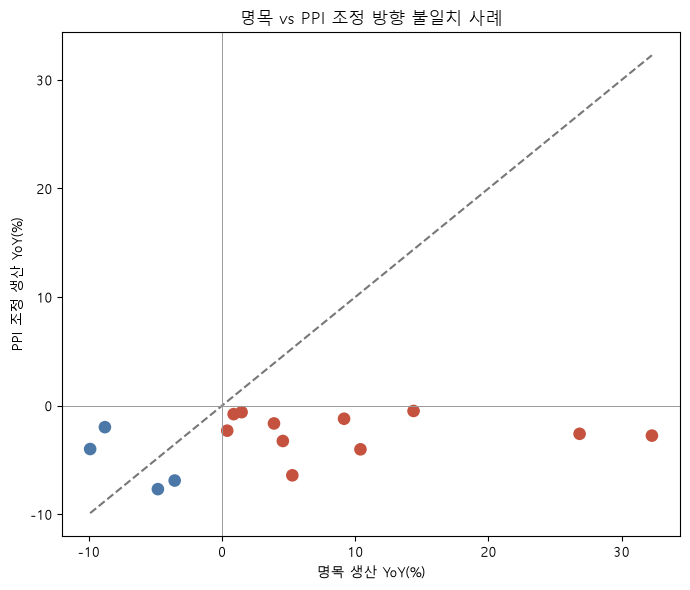

| industry | quarter | nominal_production_yoy | ppi_adjusted_production_yoy | ppi_mapping_grade | sign_agreement | pct5_threshold_agreement |
| --- | --- | --- | --- | --- | --- | --- |
| 목재종이 | 2022Q1 | 10.392 | -4.022 | A | False | True |
| 음식료 | 2022Q1 | 3.901 | -1.638 | A | False | True |
| 철강 | 2022Q1 | 32.271 | -2.757 | B | False | True |
| 비금속 | 2022Q2 | 5.278 | -6.414 | A | False | False |
| 음식료 | 2022Q2 | 4.566 | -3.254 | A | False | True |
| 철강 | 2022Q2 | 26.842 | -2.592 | B | False | True |
| 철강 | 2022Q3 | 9.161 | -1.204 | B | False | True |
| 비금속 | 2022Q4 | 14.378 | -0.488 | A | False | True |
| 기계 | 2023Q1 | -3.552 | -6.896 | A | True | False |
| 기계 | 2023Q2 | 0.389 | -2.302 | A | False | True |
| 철강 | 2023Q3 | -9.899 | -3.994 | B | True | False |
| 비금속 | 2024Q1 | -4.814 | -7.687 | A | True | False |
| 운송장비 | 2024Q1 | 1.469 | -0.600 | A | False | True |
| 철강 | 2024Q1 | -8.791 | -1.978 | B | True | False |
| 음식료 | 2026Q2 | 0.873 | -0.779 | A | False | True |

부호가 갈리는 행: 11 건
5% 경계가 갈리는 행: 5 건
기록된 불일치·경계변경 행(둘 중 하나라도 해당): 15 건


| signal_label | baseline_threshold | alternative_threshold | n_rows_changed | pct_rows_changed | n_industries_changed |
| --- | --- | --- | --- | --- | --- |
| 업체수 감소 신호 | -3.000 | -2.000 | 5 | 2.780 | 3 |
| 업체수 감소 신호 | -3.000 | -3.000 | 0 | 0.000 | 0 |
| 업체수 감소 신호 | -3.000 | -5.000 | 3 | 1.670 | 1 |
| 가동 위축 신호 | -3.000 | -2.000 | 6 | 3.330 | 4 |
| 가동 위축 신호 | -3.000 | -3.000 | 0 | 0.000 | 0 |
| 가동 위축 신호 | -3.000 | -5.000 | 12 | 6.670 | 7 |
| 실질생산 위축 신호(PPI 조정) | -5.000 | -3.000 | 6 | 3.330 | 6 |
| 실질생산 위축 신호(PPI 조정) | -5.000 | -5.000 | 0 | 0.000 | 0 |
| 실질생산 위축 신호(PPI 조정) | -5.000 | -7.000 | 4 | 2.220 | 3 |

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
flag = ppi.sign_agreement.astype(bool)
ax.scatter(ppi.nominal_production_yoy, ppi.ppi_adjusted_production_yoy,
           c=np.where(flag, '#4C78A8', '#C5523F'), s=65)
lo = min(ppi.nominal_production_yoy.min(), ppi.ppi_adjusted_production_yoy.min())
hi = max(ppi.nominal_production_yoy.max(), ppi.ppi_adjusted_production_yoy.max())
ax.plot([lo, hi], [lo, hi], color='#777', ls='--')
ax.axhline(0, color='#999', lw=.7)
ax.axvline(0, color='#999', lw=.7)
ax.set(xlabel='명목 생산 YoY(%)', ylabel='PPI 조정 생산 YoY(%)', title='명목 vs PPI 조정 방향 불일치 사례')
plt.tight_layout(); plt.show()

show_table(ppi)
print('부호가 갈리는 행:', int((~flag).sum()), '건')
print('5% 경계가 갈리는 행:', int((~ppi.pct5_threshold_agreement.astype(bool)).sum()), '건')
print('기록된 불일치·경계변경 행(둘 중 하나라도 해당):', len(ppi), '건')

show_table(signal_sensitivity[['signal_label', 'baseline_threshold', 'alternative_threshold',
                                'n_rows_changed', 'pct_rows_changed', 'n_industries_changed']])

### 관찰 결과

- 15건 중 부호가 갈리는 행 11건, 5% 경계가 갈리는 행 5건이다(둘 다 해당하는 행이 있어 합쳐 15행).
- 예: 비금속 2022Q2는 명목 +5.28%·조정 −6.41%로 부호와 5% 경계가 동시에 갈린다. 철강 2022Q1은 명목 +32.27%·조정 −2.76%로 부호만 갈린다.
- 경계 민감도 표에서 최대 변동폭은 가동 위축 −5% 경계 기준 6.7%다. 이 표는 더 나은 경계를 고르기 위한 것이 아니다.

### 최종 설계에 미친 영향

PPI 조정값은 CORE의 명목 생산·Q1~Q3 상태를 자동으로 교체하지 않는다. 부호가 달라지는 사례를 병기 정보·해석 경고로만 남긴다.

## H. KEPCO 전력 강건성

### 무엇을 확인하려 했나

전력사용량(KEPCO)이 생산·고용 변화의 독립적 교차확인 지표가 될 수 있는지, 그래서 판정변수로 승격할 근거가 있는지 확인한다. `01_eda.ipynb` 보조분석(가동률·업체수)과 마찬가지로 이번에도 CONTEXT 층 후보로만 다룬다.

이 결과는 `logs/validation/outputs/kepco_robustness/*`에 저장된 실행 산출물이다.

In [30]:
print('결합 행수:', kepco_summary['n_rows_joined'], '| 비교가능 행수:', kepco_summary['n_comparable'])
print('생산-전력 부호일치:', kepco_summary['pooled']['production_vs_power']['agree_pct'], '%',
      '(n=', kepco_summary['pooled']['production_vs_power']['n'], ')')
print('고용-전력 부호일치:', kepco_summary['pooled']['employment_vs_power']['agree_pct'], '%',
      '(n=', kepco_summary['pooled']['employment_vs_power']['n'], ')')
print('업종×지표 다중검정:', kepco_summary['multiple_testing']['n_tests'], '회 중',
      'BH 보정 후 유의:', kepco_summary['multiple_testing']['n_q_below_05_bh'], '건')

show_table(kepco_completeness)
show_table(kepco_by_stage)

print('법정동 결합 비식별 비율:', kepco_summary['spatial_context']['masked_rows_pct'], '%')
print('전력자료 결합 전후 Triage 180행 stage 분포 동일:', kepco_summary['triage_invariance']['unchanged'])

결합 행수: 180 | 비교가능 행수: 130
생산-전력 부호일치: 54.5 % (n= 110 )
고용-전력 부호일치: 50.0 % (n= 130 )
업종×지표 다중검정: 20 회 중 BH 보정 후 유의: 0 건


| kicox_industry | COMPLETE | NO_DATA | PARTIAL |
| --- | --- | --- | --- |
| 기계 | 17 | 4 | 1 |
| 기타 | 17 | 0 | 1 |
| 목재종이 | 17 | 0 | 1 |
| 비금속 | 17 | 0 | 1 |
| 석유화학 | 17 | 0 | 1 |
| 섬유의복 | 17 | 0 | 1 |
| 운송장비 | 17 | 0 | 1 |
| 음식료 | 17 | 0 | 1 |
| 전기전자 | 17 | 4 | 1 |
| 철강 | 17 | 4 | 1 |
| 해당없음 | 17 | 4 | 1 |

| stage | n | power_yoy_median |
| --- | --- | --- |
| 관찰 | 88 | -0.294 |
| 우선점검 | 12 | -0.534 |
| 추가확인 | 30 | 9.582 |

법정동 결합 비식별 비율: 72.6 %
전력자료 결합 전후 Triage 180행 stage 분포 동일: True


### 관찰 결과

- 생산-전력 부호일치는 54.5%(n=110), 고용-전력 부호일치는 50.0%(n=130)로 우연(50%) 수준에 가깝다.
- 업종×(생산·고용) 20회 검정 중 5회는 원 p<0.05이지만 Benjamini–Hochberg 보정 후 유의한 것은 0건이다.
- 업종별 KEPCO API 완전성은 대부분 업종에서 17개 분기 COMPLETE이지만 기계는 4개 분기 NO_DATA·1개 분기 PARTIAL이다.
- 법정동 단위 결합은 비식별 비율이 72.6%로 높고, 법정동 코드가 없어 산단 경계와 자동으로 결합할 수 없다(상한만 제공).
- 전력자료를 결합해도 Triage 180행의 stage 분포와 해시는 결합 전후 동일하다(`unchanged=True`).

### 최종 설계에 미친 영향

전력사용량은 판정변수로 승격하지 않고 CONTEXT/ACTIVITY 정보로만 쓴다. Triage 판정 자체는 이 자료를 결합하기 전과 후가 같다.

## I. 최종 모형 선택과 경로 재검증

### 무엇을 확인하려 했나

A~H에서 확인한 근거를 모아 각 후보의 최종 역할을 정리하고, Triage 추가확인 35건 → ELECTRE/SMAA 입력 35건 → 최종 선택패널 35건으로 이어지는 경로에서 키가 정확히 일치하고 Triage 단계를 덮어쓰지 않는지(overwrite 0건) 이 노트북에서 다시 검증한다.

In [31]:
comparison = pd.DataFrame([
    ['Q1~Q3', '현상진단', '직관적·역할 분리', '확인 우선순위 없음', 'CORE'],
    ['ELECTRE TRI-B', '다기준 범주분류(비보상)', 'parameter 구조를 명시적으로 표현', 'C3b 6개 조합 모두 0.95 미달, 외적 정당화 부족(PART B·D)', '추가확인 선택적 재검토'],
    ['SMAA-TRI', '파라미터 불확실성 표시', '수용도·가능단계 공개', '정답 weight·위기확률 제공 안함(PART C)', '재검토 시 참고 지표'],
    ['Rule-based Triage', '1차 선별', '설명·감사·운영이 쉬움', '운영 threshold 민감(PART E), 정답 label 부재', '현재 1차 구조'],
], columns=['후보', '목적', '장점', '실제 확인된 한계', '최종 역할'])
show_table(comparison)

| 후보 | 목적 | 장점 | 실제 확인된 한계 | 최종 역할 |
| --- | --- | --- | --- | --- |
| Q1~Q3 | 현상진단 | 직관적·역할 분리 | 확인 우선순위 없음 | CORE |
| ELECTRE TRI-B | 다기준 범주분류(비보상) | parameter 구조를 명시적으로 표현 | C3b 6개 조합 모두 0.95 미달, 외적 정당화 부족(PART B·D) | 추가확인 선택적 재검토 |
| SMAA-TRI | 파라미터 불확실성 표시 | 수용도·가능단계 공개 | 정답 weight·위기확률 제공 안함(PART C) | 재검토 시 참고 지표 |
| Rule-based Triage | 1차 선별 | 설명·감사·운영이 쉬움 | 운영 threshold 민감(PART E), 정답 label 부재 | 현재 1차 구조 |

In [32]:
check_keys = set(map(tuple, triage.loc[triage.stage.eq('추가확인'), ['industry', 'quarter']].to_numpy()))
source_keys = set(map(tuple, source_review[['industry', 'quarter']].to_numpy()))
output_keys = set(map(tuple, review[['industry', 'quarter']].to_numpy()))

assert check_keys == source_keys == output_keys and len(check_keys) == 35
assert review.triage_stage_preserved.eq('추가확인').all()
overwritten = review.loc[~review.triage_stage_preserved.eq('추가확인')]

print('Triage 추가확인:', len(check_keys), '건 | 원천 ELECTRE 입력:', len(source_keys),
      '건 | 최종 선택패널:', len(output_keys), '건')
print('세 키 집합 완전 일치:', check_keys == source_keys == output_keys)
print('Triage 단계를 덮어쓴 행(overwrite):', len(overwritten), '건')

electre_stage_dist = review.electre_stage.value_counts().reindex(
    ['PRIORITY', 'CHECK', 'OBSERVE', 'UNDETERMINED'], fill_value=0)
print('추가확인 35건의 ELECTRE 단일 배정 결과 분포:')
print(electre_stage_dist.to_string())

Triage 추가확인: 35 건 | 원천 ELECTRE 입력: 35 건 | 최종 선택패널: 35 건
세 키 집합 완전 일치: True
Triage 단계를 덮어쓴 행(overwrite): 0 건
추가확인 35건의 ELECTRE 단일 배정 결과 분포:
electre_stage
PRIORITY        20
CHECK            9
OBSERVE          2
UNDETERMINED     4


### 관찰 결과

- Triage 추가확인 35건, 원천 ELECTRE/SMAA 입력 35건, 최종 선택패널 35건의 `(industry, quarter)` 키가 정확히 일치한다.
- `triage_stage_preserved`가 전부 '추가확인'이라 Triage 단계를 덮어쓴 행은 0건이다.
- 35건의 ELECTRE 단일 배정 결과는 PRIORITY 20건·CHECK 9건·UNDETERMINED 4건·OBSERVE 2건이며, 어느 것도 Triage의 우선점검·관찰 단계를 자동으로 바꾸지 않는다.

### Decision Box — 왜 ELECTRE를 전체 자동판정에 쓰지 않고 추가확인 재검토로 한정했는가

- **문제:** ELECTRE TRI-B는 180행 전체의 주 분류모형 후보로 등록되고 구현 검사를 통과했다(PART A). 이 구조를 전체 자동판정에 쓸지, 아니면 범위를 좁혀 쓸지 결정해야 했다.
- **선택:** ELECTRE/SMAA는 전체 180행 자동판정에 쓰지 않는다. Triage가 이미 추가확인으로 분류한 35건에 한해서만 선택적 재검토 계층으로 쓰고, 관찰·우선점검 단계를 자동으로 올리거나 내리지 않는다.
- **근거:** 자료개정 교란 강건성 C3b는 6개 조합 모두 사전 기준 0.95를 충족하지 못했다(최댓값 0.938359, PART B). 파라미터 표집 아래 추가확인 35건 중 29건은 가능단계가 2개 이상으로 단일 필연 배정이 없다(PART C). 독립감사는 표본 공통 배정을 필연으로 표기한 문제, RC/VRC 독립성 문제 등 5건을 CONFIRMED로 남겼다(PART D). 시점을 분리한 검증에서도 두 모형 중 어느 쪽이 일반적으로 우월한지는 확인되지 않았다(PART F).
- **결론에 미친 영향:** 추가확인 35건의 ELECTRE 결과(PRIORITY 20·CHECK 9·UNDETERMINED 4·OBSERVE 2)는 검토 순서를 매기거나 Triage-ELECTRE 불일치를 확인하는 용도로만 쓰고(PART C `boundary_action`), Triage 단계 자체는 덮어쓰지 않는다(overwrite 0건, 위 검증 참고).

# 정리

## 확인한 것

- ELECTRE TRI-B 점 배정 6개 조합은 자료개정 교란 강건성 기준(C3b≥0.95)을 모두 충족하지 못했다(최댓값 0.938359).
- SMAA-TRI 파라미터 표집에서 추가확인 35건 중 29건은 가능단계가 2개 이상이다.
- 독립감사는 14개 이전 지적 중 CONFIRMED 5건, PARTIALLY_CONFIRMED 6건을 남겼고 최종 판단은 HYBRID다.
- `triage_rule.py`의 `compute_axes`·`apply_rule`을 이 노트북에서 다시 불러와 baseline(180행, 관찰128/추가확인35/우선점검17)과 15개 변형 사양을 재실행했고, 저장된 `sensitivity_own_rules.csv`와 셀 단위로 정확히 일치했다(불일치 0건).
- Triage 추가확인 35건, 원천 ELECTRE 입력 35건, 최종 선택패널 35건의 키가 일치하며 overwrite는 0건이다.

## 말할 수 없는 것

- 어느 후보도 현장 정답·인과효과·정책효과를 검증하지 못했다.
- rolling/hybrid 시점분리 검증은 미래 예측 성능이 아니라 과거 자료 기반 운영범위 점검이며, 어느 모형이 일반적으로 우월한지 답하지 않는다.
- PPI 조정·KEPCO 전력은 보조 맥락 신호이며 판정변수로 승격되지 않았다.

## 다음 단계

모형은 확인 순서를 정하지만 변화의 원인을 자동으로 설명하지 못한다. 판정을 덮어쓰지 않는 외부자료(무역·전력·PPI 등)를 맥락·교차확인 층으로 어떻게 붙이는지는 다음 단계에서 확인한다.

- 다음: `05_external_evidence.ipynb`